In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import transforms
from torchvision.datasets import ImageFolder
from sklearn.utils.class_weight import compute_class_weight
from tqdm import tqdm
import pennylane as qml
from pennylane.qnn import TorchLayer

# ══════════════════════════════════════════════════════════════════════════════
# HybridResNet v3 — QNI-CCP ONLY TRAINING
#
# PURPOSE:
#   Isolate the effect of QNI-CCP (latent-space perturbation) alone,
#   exactly as done for the Malimg dataset in the paper.
#   No pixel-space attacks (FGSM/PGD) are used here.
#   This lets you directly compare:
#     Clean baseline  →  +QNI-CCP only  →  +Full QSLP (QNI+FGSM+PGD)
#
# LOSS FORMULA (QNI-CCP only):
#   loss = 0.625 * loss_clean      (scaled up to compensate for removed terms)
#        + 0.250 * loss_qni_ccp    (latent-space perturbation toward wrong centroid)
#        + 0.125 * centroid_reg    (pulls features toward correct centroid)
#
# WHY RESCALED WEIGHTS:
#   Original full QSLP weights sum to 1.00:
#     clean=0.50, qni=0.15, fgsm=0.10, pgd=0.15, centroid=0.10
#   Removing FGSM(0.10) + PGD(0.15) leaves 0.75 total.
#   We rescale the remaining three so they still sum to 1.00:
#     clean    = 0.50/0.75 = 0.625
#     qni_ccp  = 0.15/0.75 = 0.200  → rounded to 0.250 to give QNI more weight
#     centroid = 0.10/0.75 = 0.125
#   This keeps the relative balance between clean and QNI-CCP meaningful.
#   If you want exact proportional rescaling: clean=0.667, qni=0.200, centroid=0.133
#
# ARCHITECTURE (unchanged from v3):
#   (B,1,32,32) → stem → stage1 → stage2 → stage3 → GAP(B,64)
#   → QuantumBridge(64→16) → QuantumLayer(16→24) → Classifier(24→10)
#
# WHAT QNI-CCP DOES:
#   After GAP, we have a 64-dim feature vector z.
#   QNI-CCP perturbs z toward a WRONG class centroid,
#   weighted by gradient sensitivity (which features matter most).
#   Training on these perturbed features teaches the model to resist
#   latent-space manipulation — directly hardening the quantum layer input.
# ══════════════════════════════════════════════════════════════════════════════


# ─────────────────────────────────────────────
# SEEDING
# ─────────────────────────────────────────────
def seed_all(seed=42):
    torch.manual_seed(seed)
    np.random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

seed_all(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


# ─────────────────────────────────────────────
# CONFIG
# ─────────────────────────────────────────────
n_qubits     = 8
q_depth      = 6
q_out_dim    = 3 * n_qubits    # 24 — three Pauli measurements per qubit
batch_size   = 32
num_classes  = 10
num_epochs   = 60              # fine-tuning; fewer than clean training
lr           = 0.0002          # lower than clean training to preserve learned weights
weight_decay = 3e-4

# QNI-CCP hyperparameters (from paper, same as Malimg experiment)
EPSILON_Q  = 1.0               # perturbation scale (α=β=1.0 from paper)

# Loss weights — QNI-CCP only (rescaled to sum to 1.00)
W_CLEAN    = 0.625             # dominant: preserve clean accuracy
W_QNI      = 0.250             # QNI-CCP: latent-space robustness
W_CENTROID = 0.125             # centroid reg: compact feature clusters


# ─────────────────────────────────────────────
# TRANSFORMS — identical to v3
# ─────────────────────────────────────────────
train_transform = transforms.Compose([
    transforms.Grayscale(1),
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])
eval_transform = transforms.Compose([
    transforms.Grayscale(1),
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])


# ─────────────────────────────────────────────
# DATASETS & LOADERS
# ─────────────────────────────────────────────
TRAIN_PATH = 'virus_MNIST dataset/train_balanced_v2'
VAL_PATH   = 'virus_MNIST dataset/val'
TEST_PATH  = 'virus_MNIST dataset/test'

try:
    train_dataset = ImageFolder(TRAIN_PATH, transform=train_transform)
    val_dataset   = ImageFolder(VAL_PATH,   transform=eval_transform)
    test_dataset  = ImageFolder(TEST_PATH,  transform=eval_transform)
    print(f"Datasets loaded: {len(train_dataset)} train | "
          f"{len(val_dataset)} val | {len(test_dataset)} test")
except Exception as e:
    print(f"Error loading datasets: {e}")
    raise

try:
    labels = [label for _, label in train_dataset.samples]
    class_weights = compute_class_weight(
        class_weight='balanced', classes=np.unique(labels), y=labels
    )
    class_weight_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)
    print("Class weights computed:", np.round(class_weights, 3))
except Exception as e:
    print(f"Could not compute class weights: {e}. Using uniform.")
    class_weight_tensor = torch.ones(num_classes).to(device)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True,
                          num_workers=4, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False,
                          num_workers=4, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False,
                          num_workers=4, pin_memory=True)


# ══════════════════════════════════════════════════════════════════════════════
# FULL MODEL DEFINITION — HybridResNet v3 (unchanged)
# ══════════════════════════════════════════════════════════════════════════════

class FocalLoss(nn.Module):
    """
    Focal Loss with class weighting and label smoothing.
    Identical to clean training v3 — keeps the loss function consistent.
    Data flow: logits (B,10) → per-sample CE → focal modulation → mean scalar
    """
    def __init__(self, weight=None, gamma=2.0, label_smoothing=0.15):
        super().__init__()
        self.weight          = weight
        self.gamma           = gamma
        self.label_smoothing = label_smoothing

    def forward(self, inputs, targets):
        ce_loss    = F.cross_entropy(
            inputs, targets,
            weight          = self.weight,
            label_smoothing = self.label_smoothing,
            reduction       = 'none'
        )
        pt         = torch.exp(-ce_loss)
        focal_loss = ((1 - pt) ** self.gamma) * ce_loss
        return focal_loss.mean()


# ─────────────────────────────────────────────
# QUANTUM CIRCUIT — identical to v3
# ─────────────────────────────────────────────
dev = qml.device("default.qubit", wires=n_qubits)

@qml.qnode(dev, interface="torch", diff_method="backprop")
def quantum_circuit(inputs, weights):
    # Angle encoding: RY + RZ per qubit from the 16 bridge outputs
    for i in range(n_qubits):
        qml.RY(inputs[..., i],            wires=i)   # first 8 → RY rotation
        qml.RZ(inputs[..., i + n_qubits], wires=i)   # next  8 → RZ rotation

    # Variational layers: brick CRZ entanglement + data re-uploading
    for l in range(weights.shape[0]):
        if l % 2 == 0:
            for i in range(0, n_qubits - 1, 2):
                qml.CRZ(weights[l, i, 2], wires=[i, i + 1])   # even pairs
        else:
            for i in range(1, n_qubits - 1, 2):
                qml.CRZ(weights[l, i, 2], wires=[i, i + 1])   # odd pairs

        # Re-upload: trainable weight + input angle fused at each layer
        for i in range(n_qubits):
            qml.RY(weights[l, i, 0] + inputs[..., i],            wires=i)
            qml.RZ(weights[l, i, 1] + inputs[..., i + n_qubits], wires=i)

    # 3-axis Pauli measurement → 24 expectation values (Z, X, Y per qubit)
    measurements = []
    for i in range(n_qubits):
        measurements.append(qml.expval(qml.PauliZ(i)))
        measurements.append(qml.expval(qml.PauliX(i)))
        measurements.append(qml.expval(qml.PauliY(i)))
    return measurements

weight_shapes = {"weights": (q_depth, n_qubits, 3)}


class SEBlock(nn.Module):
    """
    Squeeze-and-Excitation channel attention.
    Data flow: (B,C,H,W) → GAP → FC → Sigmoid → channel rescale → (B,C,H,W)
    Tells the network which feature channels are most informative per sample.
    """
    def __init__(self, channels, reduction=4):
        super().__init__()
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.fc   = nn.Sequential(
            nn.Linear(channels, max(channels // reduction, 4), bias=False),
            nn.ReLU(),
            nn.Linear(max(channels // reduction, 4), channels, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x):
        b, c, _, _ = x.shape
        scale = self.pool(x).view(b, c)
        scale = self.fc(scale).view(b, c, 1, 1)
        return x * scale


class ResBlock(nn.Module):
    """
    Residual block with SE attention and stochastic depth.
    Data flow: x → [Conv→BN→ReLU→Dropout→Conv→BN] → SE → stoch_depth → +skip → ReLU
    """
    def __init__(self, in_ch, out_ch, stride=1, dropout=0.20, drop_path=0.10):
        super().__init__()
        self.conv_block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, stride=stride, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Dropout2d(dropout),
            nn.Conv2d(out_ch, out_ch, 3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(out_ch)
        )
        self.se             = SEBlock(out_ch)
        self.drop_path_rate = drop_path
        self.skip = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 1, stride=stride, bias=False),
            nn.BatchNorm2d(out_ch)
        ) if (stride != 1 or in_ch != out_ch) else nn.Identity()
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        out = self.conv_block(x)
        out = self.se(out)
        if self.training and self.drop_path_rate > 0:
            keep_prob     = 1 - self.drop_path_rate
            random_tensor = (
                torch.rand(x.shape[0], 1, 1, 1, device=x.device) < keep_prob
            ).float()
            out = out * random_tensor / keep_prob
        return self.relu(out + self.skip(x))


class QuantumBridge(nn.Module):
    """
    Compresses 64-dim backbone features → 16 quantum angles (2 per qubit).
    Data flow: (B,64) → Linear→LayerNorm→GELU→Dropout→Linear → sigmoid scale → (B,16)
    """
    def __init__(self, in_features, n_qubits):
        super().__init__()
        self.project = nn.Sequential(
            nn.Linear(in_features, 32),
            nn.LayerNorm(32),
            nn.GELU(),
            nn.Dropout(0.35),
            nn.Linear(32, n_qubits * 2)
        )
        self.angle_scale = nn.Parameter(torch.ones(n_qubits * 2) * torch.pi)
        self.angle_bias  = nn.Parameter(torch.zeros(n_qubits * 2))

    def forward(self, x):
        x = self.project(x)
        return self.angle_scale * torch.sigmoid(x) + self.angle_bias


class HybridResNet(nn.Module):
    """
    HybridResNet v3 — full quantum-classical architecture.

    Data flow:
      (B,1,32,32)
      → stem    (1→16 Conv)                    → (B,16,32,32)
      → stage1  (ResBlock 16→16 ×2)            → (B,16,32,32)
      → stage2  (ResBlock 16→32, stride=2 ×2)  → (B,32,16,16)
      → stage3  (ResBlock 32→64, stride=2 ×2)  → (B,64, 8, 8)
      → GAP     → flatten                      → (B,64)
      → bridge  (QuantumBridge 64→16)          → (B,16)
      → q_layer (PennyLane circuit)            → (B,24)
      → classifier (Linear 24→48→10)           → (B,10)

    The GAP output (B,64) is the latent space that QNI-CCP operates on.
    The FeatureHook below intercepts this layer to extract it.
    """
    def __init__(self, n_qubits, q_out_dim, num_classes, dropout=0.35):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(16),
            nn.ReLU(inplace=True)
        )
        self.stage1 = nn.Sequential(
            ResBlock(16, 16, drop_path=0.10),
            ResBlock(16, 16, drop_path=0.10)
        )
        self.stage2 = nn.Sequential(
            ResBlock(16, 32, stride=2, drop_path=0.15),
            ResBlock(32, 32,           drop_path=0.15)
        )
        self.stage3 = nn.Sequential(
            ResBlock(32, 64, stride=2, drop_path=0.20),
            ResBlock(64, 64,           drop_path=0.20)
        )
        self.gap        = nn.AdaptiveAvgPool2d(1)   # ← QNI-CCP hook attaches HERE
        self.bridge     = QuantumBridge(in_features=64, n_qubits=n_qubits)
        self.q_layer    = TorchLayer(quantum_circuit, weight_shapes)
        self.classifier = nn.Sequential(
            nn.Linear(q_out_dim, q_out_dim * 2),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(q_out_dim * 2, num_classes)
        )
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, (nn.BatchNorm2d, nn.LayerNorm)):
                nn.init.ones_(m.weight); nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight)
                if m.bias is not None: nn.init.zeros_(m.bias)

    def forward(self, x):
        x = self.stem(x)                 # (B,16,32,32)
        x = self.stage1(x)               # (B,16,32,32)
        x = self.stage2(x)               # (B,32,16,16)
        x = self.stage3(x)               # (B,64, 8, 8)
        x = self.gap(x)                  # (B,64, 1, 1) ← hook reads here
        x = x.view(x.size(0), -1)        # (B,64)
        x = self.bridge(x)               # (B,16)
        x = self.q_layer(x)              # (B,24)
        return self.classifier(x)        # (B,10)


# ══════════════════════════════════════════════════════════════════════════════
# QNI-CCP COMPONENTS
# ══════════════════════════════════════════════════════════════════════════════

class FeatureHook:
    """
    Intercepts the GAP layer output mid-forward-pass.
    Needed because QNI-CCP requires the 64-dim latent vector BEFORE the bridge,
    but forward() is a single chain with no intermediate return.

    Usage:
      hook = FeatureHook(model.gap)
      _ = model(x)            # forward fires; hook captures GAP output
      z = hook.features        # (B, 64, 1, 1)
      hook.remove()            # deregister — prevents memory leak
    """
    def __init__(self, layer):
        self.features = None
        self._handle  = layer.register_forward_hook(self._capture)

    def _capture(self, module, input, output):
        self.features = output   # (B, 64, 1, 1) from GAP

    def remove(self):
        self._handle.remove()


def get_gap_features(model, x):
    """
    Returns flattened GAP output (B, 64) — the latent space for QNI-CCP.
    Uses no_grad since this is only for centroid computation and centroid reg.

    Data flow: x → full forward (hook fires) → (B,64,1,1) → flatten → (B,64)
    """
    hook = FeatureHook(model.gap)
    with torch.no_grad():
        _ = model(x)
    z = hook.features.view(hook.features.size(0), -1)   # (B,64,1,1) → (B,64)
    hook.remove()
    return z


def compute_class_centroids(model, dataloader, device, num_classes):
    """
    Computes mean GAP feature vector per class over the full training set.
    μ_c = (1/N_c) * Σ z_i  for all i where y_i == c

    These centroids serve two roles:
      1. QNI-CCP: push features TOWARD wrong-class centroid (adversarial)
      2. Centroid reg: pull features TOWARD correct-class centroid (regularise)

    Recomputed every 5 epochs as model weights (and thus features) shift.
    Returns: (num_classes, 64) tensor
    """
    model.eval()
    sum_features = torch.zeros(num_classes, 64, device=device)
    count        = torch.zeros(num_classes,     device=device)

    with torch.no_grad():
        for x, y in tqdm(dataloader, desc="Computing centroids", leave=False):
            x, y  = x.to(device), y.to(device)
            feats = get_gap_features(model, x)    # (B, 64)
            for c in range(num_classes):
                mask = (y == c)
                if mask.sum() > 0:
                    sum_features[c] += feats[mask].sum(dim=0)
                    count[c]        += mask.sum()

    count     = count.clamp(min=1.0)
    centroids = sum_features / count.unsqueeze(1)   # (num_classes, 64)
    return centroids


def qni_ccp_loss(model, x, y, centroids, epsilon_q=1.0):
    """
    Computes QNI-CCP adversarial loss in latent space.

    Steps:
      1. Extract z (B,64) from GAP via hook, WITH gradient tracking on z
      2. Pass z through bridge → q_layer → classifier to get logits
      3. Compute CE loss → backward → z.grad = sensitivity S
      4. Pick random wrong class c' per sample → get centroid μ_{c'}
      5. Perturb: z' = z + ε_q * (S_norm ⊙ (μ_{c'} - z))
         → pushes z toward wrong-class centroid, focused on sensitive dims
      6. Forward z' through bridge → q_layer → classifier → CE loss

    Why the hook + manual bridge pass (not just model(x) twice):
      We need grad w.r.t. z (the latent vector), not w.r.t. x (the input).
      By detaching z from the backbone and enabling requires_grad on z alone,
      we isolate sensitivity to the latent space — exactly what the paper does.

    Returns: scalar CE loss on perturbed latent features
    """
    model.eval()   # consistent BN/Dropout during sensitivity computation

    # Step 1: extract z via hook, then re-attach gradient
    hook  = FeatureHook(model.gap)
    _     = model(x)                                           # full forward; hook fires
    z_raw = hook.features.view(hook.features.size(0), -1)     # (B,64,1,1) → (B,64)
    hook.remove()

    z = z_raw.detach().requires_grad_(True)    # fresh leaf tensor — grad flows through z only

    # Step 2: recompute the post-GAP path to get logits
    # This replicates bridge → q_layer → classifier starting from z
    angles = model.bridge(z)           # (B,64) → (B,16) quantum angles
    q_out  = model.q_layer(angles)     # (B,16) → (B,24) Pauli expectation values
    logits = model.classifier(q_out)   # (B,24) → (B,10) class logits

    # Step 3: compute sensitivity S = ∂L/∂z
    loss_sens = F.cross_entropy(logits, y)
    loss_sens.backward()                       # z.grad now holds (B,64) sensitivity

    S      = z.grad.detach()                               # (B,64)
    S_norm = S / (S.norm(dim=1, keepdim=True) + 1e-8)     # ℓ2 normalise per sample

    # Step 4: pick a random wrong class c' ≠ y for each sample in the batch
    z_det = z.detach()
    wrong_classes = []
    for i in range(y.size(0)):
        candidates = [c for c in range(centroids.size(0)) if c != y[i].item()]
        picked     = candidates[torch.randint(0, len(candidates), (1,)).item()]
        wrong_classes.append(picked)
    wrong_idx  = torch.tensor(wrong_classes, device=device)   # (B,)
    mu_c_prime = centroids[wrong_idx]                         # (B,64) wrong-class centroids

    # Step 5: sensitivity-weighted perturbation toward wrong centroid
    # Δ_base = μ_{c'} - z   (direction from current features to wrong centroid)
    # z' = z + ε_q * (S_norm ⊙ Δ_base)
    delta       = mu_c_prime - z_det                          # (B,64) direction
    z_perturbed = z_det + epsilon_q * (S_norm * delta)        # (B,64) perturbed features

    # Step 6: forward z' through bridge→q_layer→classifier → CE loss
    model.train()   # restore train mode so BN/Dropout behave correctly for training loss
    angles_p  = model.bridge(z_perturbed)
    q_out_p   = model.q_layer(angles_p)
    logits_p  = model.classifier(q_out_p)
    return F.cross_entropy(logits_p, y)    # scalar — how well model classifies perturbed z


# ══════════════════════════════════════════════════════════════════════════════
# TRAINING & EVALUATION
# ══════════════════════════════════════════════════════════════════════════════

def train_qni_epoch(model, train_loader, optimizer, centroids, device):
    """
    One epoch of QNI-CCP only training.

    Three losses per batch:
      1. loss_clean   : CE on normal images       — weight 0.625
      2. loss_qni     : CE on latent-perturbed z  — weight 0.250
      3. centroid_reg : MSE(z_clean, μ_correct)   — weight 0.125

    The centroid reg term pulls clean features toward their correct class mean,
    making the latent space more compact and reducing sensitivity to perturbations.

    Returns: (avg_combined_loss, clean_accuracy_this_epoch)
    """
    model.train()
    total_loss, correct, total = 0.0, 0, 0

    for x, y in tqdm(train_loader, desc="QNI-CCP Training", leave=False):
        x, y = x.to(device), y.to(device)

        # ── Loss 1: Clean forward pass ────────────────────────────
        # Standard CE on unperturbed images.
        # Weight 0.625: dominant term — clean accuracy is primary objective.
        model.train()
        logits_clean = model(x)                           # (B,10)
        loss_clean   = F.cross_entropy(logits_clean, y)   # scalar

        # ── Loss 2: QNI-CCP (latent-space perturbation) ──────────
        # Perturbs the 64-dim GAP features z toward a wrong class centroid,
        # weighted by ∂L/∂z (gradient sensitivity).
        # Passes perturbed z through bridge→q_layer→classifier and computes CE.
        # Weight 0.250: this is the core defence mechanism being studied.
        loss_qni = qni_ccp_loss(model, x, y, centroids, EPSILON_Q)

        # ── Loss 3: Centroid regularisation ───────────────────────
        # MSE between clean GAP features and the correct class centroid.
        # Pulls features tighter around their class mean.
        # More compact clusters → less overlap → less vulnerable to QNI-CCP.
        # Weight 0.125: auxiliary, keeps feature space well-organised.
        z_clean      = get_gap_features(model, x)          # (B,64) no-grad
        centroid_reg = ((z_clean - centroids[y]) ** 2).mean()  # scalar MSE

        # ── Combined loss ─────────────────────────────────────────
        # Weights sum to 1.00: 0.625 + 0.250 + 0.125 = 1.000
        loss = (W_CLEAN    * loss_clean   +   # 0.625
                W_QNI      * loss_qni     +   # 0.250
                W_CENTROID * centroid_reg)     # 0.125

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item()
        correct    += (logits_clean.argmax(1) == y).sum().item()
        total      += y.size(0)

    return total_loss / len(train_loader), correct / total


def evaluate_clean(model, dataloader, device):
    """
    Standard evaluation on unperturbed data.
    Data flow: images → model (no grad) → argmax → accuracy
    Returns: (avg_loss, accuracy)
    """
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for x, y in dataloader:
            x, y       = x.to(device), y.to(device)
            logits     = model(x)
            total_loss += F.cross_entropy(logits, y).item()
            correct    += (logits.argmax(1) == y).sum().item()
            total      += y.size(0)
    return total_loss / len(dataloader), correct / total


def evaluate_qni_robustness(model, dataloader, device, centroids):
    """
    Evaluates model accuracy when features are perturbed by QNI-CCP at test time.
    This measures how robust the model is to latent-space perturbations.

    Data flow per batch:
      x → qni_ccp_loss (get z', run through bridge→q→classifier) → accuracy

    Returns: accuracy under QNI-CCP perturbation
    """
    model.eval()
    correct, total = 0, 0

    for x, y in tqdm(dataloader, desc="QNI Robustness Eval", leave=False):
        x, y = x.to(device), y.to(device)

        # Apply QNI-CCP perturbation to get perturbed z
        hook  = FeatureHook(model.gap)
        _     = model(x)
        z_raw = hook.features.view(hook.features.size(0), -1)
        hook.remove()

        z = z_raw.detach().requires_grad_(True)
        angles = model.bridge(z)
        q_out  = model.q_layer(angles)
        logits = model.classifier(q_out)
        loss_sens = F.cross_entropy(logits, y)
        loss_sens.backward()

        S_norm = z.grad.detach()
        S_norm = S_norm / (S_norm.norm(dim=1, keepdim=True) + 1e-8)

        z_det = z.detach()
        wrong_classes = []
        for i in range(y.size(0)):
            candidates = [c for c in range(centroids.size(0)) if c != y[i].item()]
            picked     = candidates[torch.randint(0, len(candidates), (1,)).item()]
            wrong_classes.append(picked)
        wrong_idx  = torch.tensor(wrong_classes, device=device)
        mu_c_prime = centroids[wrong_idx]

        delta       = mu_c_prime - z_det
        z_perturbed = z_det + EPSILON_Q * (S_norm * delta)

        with torch.no_grad():
            angles_p = model.bridge(z_perturbed)
            q_out_p  = model.q_layer(angles_p)
            logits_p = model.classifier(q_out_p)
            correct += (logits_p.argmax(1) == y).sum().item()
            total   += y.size(0)

    return correct / total


# ══════════════════════════════════════════════════════════════════════════════
# MAIN SCRIPT
# ══════════════════════════════════════════════════════════════════════════════

# ── Build model and load pretrained clean checkpoint ─────────────────────────
model = HybridResNet(
    n_qubits    = n_qubits,
    q_out_dim   = q_out_dim,
    num_classes = num_classes,
    dropout     = 0.35
).to(device)

# ── Build model (train from scratch — matches original Malimg methodology) ───
# No checkpoint loading. QNI-CCP trains from epoch 1, same as the paper.
model = HybridResNet(
    n_qubits    = n_qubits,
    q_out_dim   = q_out_dim,
    num_classes = num_classes,
    dropout     = 0.35
).to(device)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total trainable parameters: {total_params:,}")
print("Training from scratch with QNI-CCP from epoch 1 (original Malimg methodology)")

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total trainable parameters: {total_params:,}")

# ── Optimizer ────────────────────────────────────────────────────────────────
optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', patience=5, factor=0.5
)

loss_fn = FocalLoss(weight=class_weight_tensor, gamma=2.0, label_smoothing=0.15)

# ── Initial centroid computation ──────────────────────────────────────────────
print("\nComputing initial class centroids...")
centroids = compute_class_centroids(model, train_loader, device, num_classes)
print(f"Centroids shape: {centroids.shape}")   # (10, 64)

# ── Training loop ─────────────────────────────────────────────────────────────
best_val_acc               = 0.0
early_stopping_patience    = 12
epochs_without_improvement = 0
train_losses, val_losses   = [], []
train_accs,   val_accs     = [], []

print(f"\nStarting QNI-CCP Training for {num_epochs} epochs")
print(f"Loss weights: clean={W_CLEAN} | QNI-CCP={W_QNI} | centroid={W_CENTROID}")
print(f"QNI-CCP ε_q={EPSILON_Q} | No pixel-space attacks (FGSM/PGD disabled)")
print("=" * 70)

for epoch in range(1, num_epochs + 1):

    # Recompute centroids every 5 epochs — features drift as model updates
    if epoch % 5 == 0:
        print(f"  🔄 Recomputing centroids at epoch {epoch}...")
        centroids = compute_class_centroids(model, train_loader, device, num_classes)

    train_loss, train_acc = train_qni_epoch(
        model, train_loader, optimizer, centroids, device
    )
    val_loss, val_acc = evaluate_clean(model, val_loader, device)
    scheduler.step(val_loss)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    print(f"Epoch [{epoch:02d}/{num_epochs}] | LR: {optimizer.param_groups[0]['lr']:.6f}")
    print(f"  Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"  Val   Loss: {val_loss:.4f}  | Val   Acc: {val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc               = val_acc
        epochs_without_improvement = 0
        torch.save({
            'epoch':            epoch,
            'model_state_dict': model.state_dict(),
            'val_acc':          val_acc,
            'val_loss':         val_loss,
            'config': {
                'n_qubits':    n_qubits,
                'q_out_dim':   q_out_dim,
                'num_classes': num_classes,
                'training':    'QNI-CCP_only',
                'epsilon_q':   EPSILON_Q,
                'w_clean':     W_CLEAN,
                'w_qni':       W_QNI,
                'w_centroid':  W_CENTROID,
            }
        }, "hybrid_resnet_v3_qni_only.pth")
        print(f"  💾 Best model saved (Val Acc: {best_val_acc:.4f})")
    else:
        epochs_without_improvement += 1
        print(f"  🕒 No improvement for {epochs_without_improvement} epoch(s).")

    if epochs_without_improvement >= early_stopping_patience:
        print(f"\n⏹️  Early stopping at epoch {epoch}.")
        break

    print("-" * 70)

print(f"\n✅ QNI-CCP training complete. Best Val Acc: {best_val_acc:.4f}")

# ── Final evaluation ──────────────────────────────────────────────────────────
print("\n" + "=" * 70)
print("FINAL EVALUATION — QNI-CCP ONLY MODEL")
print("=" * 70)

checkpoint = torch.load("hybrid_resnet_v3_qni\
.pth", map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])

# Recompute test-time centroids from training set
centroids_final = compute_class_centroids(model, train_loader, device, num_classes)

_, clean_acc = evaluate_clean(model, test_loader, device)
qni_acc      = evaluate_qni_robustness(model, test_loader, device, centroids_final)

print(f"\n  Clean Test Accuracy       : {clean_acc:.4f}  ({clean_acc*100:.1f}%)")
print(f"  Under QNI-CCP Perturbation: {qni_acc:.4f}  ({qni_acc*100:.1f}%)")
print(f"  Robustness drop           : {(clean_acc - qni_acc)*100:.1f}%")
print(f"""
COMPARISON GUIDE (match this against your Malimg results):

  Stage 1 — Clean baseline   : run your clean hybrid_resnet_NOGAN.pth on test set
  Stage 2 — QNI-CCP only     : this file  →  hybrid_resnet_v3_qni_only.pth  Stage 3 — Full QSLP        : run adversarial file with FGSM+PGD re-enabled

  Expected pattern (from paper Table 5):
    Clean baseline under QNI attack  → large accuracy drop
    QNI-CCP trained under QNI attack → much smaller drop (model learned to resist)
    Full QSLP under QNI attack       → best robustness
""")

Using device: cuda
Datasets loaded: 48498 train | 4837 val | 3458 test
Class weights computed: [1.645 0.75  1.359 1.727 5.209 0.868 0.375 0.769 1.605 1.236]
Total trainable parameters: 184,234
Training from scratch with QNI-CCP from epoch 1 (original Malimg methodology)
Total trainable parameters: 184,234

Computing initial class centroids...


Centroids shape: torch.Size([10, 64])

Starting QNI-CCP Training for 60 epochs
Loss weights: clean=0.625 | QNI-CCP=0.25 | centroid=0.125
QNI-CCP ε_q=1.0 | No pixel-space attacks (FGSM/PGD disabled)


Epoch [01/60] | LR: 0.000200
  Train Loss: 1.4174 | Train Acc: 0.4468
  Val   Loss: 0.7316  | Val   Acc: 0.7656
  💾 Best model saved (Val Acc: 0.7656)
----------------------------------------------------------------------


Epoch [02/60] | LR: 0.000200
  Train Loss: 0.8277 | Train Acc: 0.6688
  Val   Loss: 0.5178  | Val   Acc: 0.8356
  💾 Best model saved (Val Acc: 0.8356)
----------------------------------------------------------------------


Epoch [03/60] | LR: 0.000200
  Train Loss: 0.6533 | Train Acc: 0.7362
  Val   Loss: 0.4165  | Val   Acc: 0.8755
  💾 Best model saved (Val Acc: 0.8755)
----------------------------------------------------------------------


...

Epoch [13/60] | LR: 0.000200
  Train Loss: 0.3663 | Train Acc: 0.8646
  Val   Loss: 0.2801  | Val   Acc: 0.9082
  🕒 No improvement for 1 epoch(s).
----------------------------------------------------------------------


Epoch [14/60] | LR: 0.000200
  Train Loss: 0.3567 | Train Acc: 0.8700
  Val   Loss: 0.2653  | Val   Acc: 0.9109
  💾 Best model saved (Val Acc: 0.9109)
----------------------------------------------------------------------
  🔄 Recomputing centroids at epoch 15...


Epoch [15/60] | LR: 0.000200
  Train Loss: 0.3301 | Train Acc: 0.8736
  Val   Loss: 0.2731  | Val   Acc: 0.9074
  🕒 No improvement for 1 epoch(s).
----------------------------------------------------------------------


Epoch [16/60] | LR: 0.000200
  Train Loss: 0.3247 | Train Acc: 0.8756
  Val   Loss: 0.2520  | Val   Acc: 0.9144
  💾 Best model saved (Val Acc: 0.9144)
----------------------------------------------------------------------


QNI-CCP Training:   9%|▉         | 138/1516 [01:21<13:08,  1.75it/s]

In [4]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import transforms
from torchvision.datasets import ImageFolder
from sklearn.utils.class_weight import compute_class_weight
from tqdm import tqdm
import pennylane as qml
from pennylane.qnn import TorchLayer

# ══════════════════════════════════════════════════════════════════════════════
# RESUME QNI-CCP TRAINING — continues from epoch 17 for 20 more epochs
#
# WHAT THIS SCRIPT DOES:
#   1. Rebuilds the exact same model architecture as the original training
#   2. Loads the best saved checkpoint (hybrid_resnet_v3_qni_only.pth)
#      which contains model weights saved at epoch 16 (Val Acc: 0.9144)
#   3. Restores the optimizer state — this preserves AdamW's momentum
#      accumulators and per-parameter learning rate history, so training
#      continues smoothly rather than restarting from cold optimizer state
#   4. Restores the scheduler state — so ReduceLROnPlateau's plateau counter
#      picks up where it left off (it had seen 16 epochs of val_loss history)
#   5. Resumes epoch counter from 17, trains for RESUME_EPOCHS more epochs
#
# WHY RESTORING OPTIMIZER STATE MATTERS:
#   AdamW keeps a running estimate of gradient mean (m) and variance (v)
#   per parameter. If you reset the optimizer, these estimates start at 0
#   and it takes several epochs to "warm up" again — causing an initial
#   accuracy dip. Restoring state avoids this.
#
# WHY RESTORING SCHEDULER STATE MATTERS:
#   ReduceLROnPlateau counts epochs without improvement to decide when to
#   halve the LR. If we don't restore it, the counter resets to 0, which
#   delays LR reduction and may let it reduce prematurely later.
# ══════════════════════════════════════════════════════════════════════════════


# ─────────────────────────────────────────────
# SEEDING — must be identical to original run
# ─────────────────────────────────────────────
def seed_all(seed=42):
    torch.manual_seed(seed)          # seeds PyTorch CPU random number generator
    np.random.seed(seed)             # seeds NumPy random number generator
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)  # seeds all GPU devices

seed_all(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


# ─────────────────────────────────────────────
# CONFIG — must be IDENTICAL to original training
# Any change here means the resumed model won't
# match the saved checkpoint's architecture.
# ─────────────────────────────────────────────
n_qubits     = 8
q_depth      = 6
q_out_dim    = 3 * n_qubits    # 24 — three Pauli measurements per qubit
batch_size   = 32
num_classes  = 10

# ── RESUME-SPECIFIC CONFIG ───────────────────
RESUME_EPOCHS      = 20         # how many MORE epochs to train (17 → 36)
RESUME_FROM_EPOCH  = 17         # epoch counter starts here (16 was last completed)
lr                 = 0.0002     # same LR as original — scheduler will adjust if needed
weight_decay       = 3e-4       # same weight decay as original

# QNI-CCP hyperparameters — unchanged from original
EPSILON_Q  = 1.0                # perturbation scale (α=β=1.0 from paper)

# Loss weights — unchanged from original
W_CLEAN    = 0.625              # dominant: preserve clean accuracy
W_QNI      = 0.250              # QNI-CCP: latent-space robustness
W_CENTROID = 0.125              # centroid reg: compact feature clusters

# Checkpoint paths
LOAD_CHECKPOINT = "hybrid_resnet_v3_qni_only.pth"   # checkpoint saved at epoch 16
SAVE_CHECKPOINT = "hybrid_resnet_v3_qni_only.pth"   # overwrite with best resumed model


# ─────────────────────────────────────────────
# TRANSFORMS — identical to original
# ─────────────────────────────────────────────
train_transform = transforms.Compose([
    transforms.Grayscale(1),            # convert to single-channel grayscale
    transforms.Resize((32, 32)),        # resize all images to 32×32
    transforms.ToTensor(),              # convert PIL image to float tensor [0,1]
    transforms.Normalize((0.5,), (0.5,))  # normalise to [-1, 1]
])
eval_transform = transforms.Compose([
    transforms.Grayscale(1),
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])


# ─────────────────────────────────────────────
# DATASETS & LOADERS — identical to original
# ─────────────────────────────────────────────
TRAIN_PATH = 'virus_MNIST dataset/train_balanced_v2'
VAL_PATH   = 'virus_MNIST dataset/val'
TEST_PATH  = 'virus_MNIST dataset/test'

try:
    train_dataset = ImageFolder(TRAIN_PATH, transform=train_transform)
    val_dataset   = ImageFolder(VAL_PATH,   transform=eval_transform)
    test_dataset  = ImageFolder(TEST_PATH,  transform=eval_transform)
    print(f"Datasets loaded: {len(train_dataset)} train | "
          f"{len(val_dataset)} val | {len(test_dataset)} test")
except Exception as e:
    print(f"Error loading datasets: {e}")
    raise

try:
    labels = [label for _, label in train_dataset.samples]   # extract integer class labels
    class_weights = compute_class_weight(
        class_weight='balanced', classes=np.unique(labels), y=labels
    )
    # balanced weighting: upweights rare classes, downweights frequent ones
    class_weight_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)
    print("Class weights computed:", np.round(class_weights, 3))
except Exception as e:
    print(f"Could not compute class weights: {e}. Using uniform.")
    class_weight_tensor = torch.ones(num_classes).to(device)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True,
                          num_workers=4, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False,
                          num_workers=4, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False,
                          num_workers=4, pin_memory=True)


# ══════════════════════════════════════════════════════════════════════════════
# MODEL DEFINITION — must be byte-for-byte identical to the original
# If anything here differs from the original, load_state_dict() will fail
# ══════════════════════════════════════════════════════════════════════════════

class FocalLoss(nn.Module):
    """
    Focal Loss: downweights easy samples (high pt) and focuses on hard ones.
    Data flow: logits (B,10) → per-sample CE → focal modulation → mean scalar
    label_smoothing=0.15 prevents overconfident predictions.
    """
    def __init__(self, weight=None, gamma=2.0, label_smoothing=0.15):
        super().__init__()
        self.weight          = weight
        self.gamma           = gamma
        self.label_smoothing = label_smoothing

    def forward(self, inputs, targets):
        ce_loss    = F.cross_entropy(
            inputs, targets,
            weight          = self.weight,
            label_smoothing = self.label_smoothing,
            reduction       = 'none'         # keep per-sample for focal modulation
        )
        pt         = torch.exp(-ce_loss)     # model confidence on correct class
        focal_loss = ((1 - pt) ** self.gamma) * ce_loss   # suppress easy samples
        return focal_loss.mean()


# ── Quantum Circuit ───────────────────────────────────────────────────────────
dev = qml.device("default.qubit", wires=n_qubits)   # PennyLane simulator, 8 qubits

@qml.qnode(dev, interface="torch", diff_method="backprop")
def quantum_circuit(inputs, weights):
    # Angle encoding: map 16 bridge outputs to qubit rotation angles
    for i in range(n_qubits):
        qml.RY(inputs[..., i],            wires=i)   # first 8 values → RY gates
        qml.RZ(inputs[..., i + n_qubits], wires=i)   # next  8 values → RZ gates

    # Variational layers: alternating brick entanglement + data re-uploading
    for l in range(weights.shape[0]):
        if l % 2 == 0:
            for i in range(0, n_qubits - 1, 2):
                qml.CRZ(weights[l, i, 2], wires=[i, i + 1])   # even-pair entanglement
        else:
            for i in range(1, n_qubits - 1, 2):
                qml.CRZ(weights[l, i, 2], wires=[i, i + 1])   # odd-pair entanglement

        for i in range(n_qubits):
            qml.RY(weights[l, i, 0] + inputs[..., i],            wires=i)   # re-upload
            qml.RZ(weights[l, i, 1] + inputs[..., i + n_qubits], wires=i)   # re-upload

    # 3-axis Pauli measurement: Z, X, Y per qubit → 24 expectation values ∈ [-1,1]
    measurements = []
    for i in range(n_qubits):
        measurements.append(qml.expval(qml.PauliZ(i)))
        measurements.append(qml.expval(qml.PauliX(i)))
        measurements.append(qml.expval(qml.PauliY(i)))
    return measurements

weight_shapes = {"weights": (q_depth, n_qubits, 3)}   # 6×8×3 = 144 trainable params


class SEBlock(nn.Module):
    """
    Squeeze-and-Excitation: learns per-channel attention weights.
    Data flow: (B,C,H,W) → GAP → FC → Sigmoid → channel rescale → (B,C,H,W)
    Tells the network which feature channels are most informative.
    """
    def __init__(self, channels, reduction=4):
        super().__init__()
        self.pool = nn.AdaptiveAvgPool2d(1)    # squeeze: (B,C,H,W) → (B,C,1,1)
        self.fc   = nn.Sequential(
            nn.Linear(channels, max(channels // reduction, 4), bias=False),  # bottleneck
            nn.ReLU(),
            nn.Linear(max(channels // reduction, 4), channels, bias=False),  # expand back
            nn.Sigmoid()   # output ∈ (0,1) per channel — attention weights
        )

    def forward(self, x):
        b, c, _, _ = x.shape
        scale = self.pool(x).view(b, c)          # (B, C) squeezed
        scale = self.fc(scale).view(b, c, 1, 1)  # (B, C, 1, 1) attention mask
        return x * scale                          # channel-wise rescaling


class ResBlock(nn.Module):
    """
    Residual block: Conv→BN→ReLU→Dropout→Conv→BN + SE + stochastic depth.
    Skip connection allows gradients to flow directly → avoids vanishing grads.
    Stochastic depth randomly drops entire blocks during training.
    Data flow: (B, in_ch, H, W) → (B, out_ch, H/stride, W/stride)
    """
    def __init__(self, in_ch, out_ch, stride=1, dropout=0.20, drop_path=0.10):
        super().__init__()
        self.conv_block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, stride=stride, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Dropout2d(dropout),              # randomly zero out entire feature maps
            nn.Conv2d(out_ch, out_ch, 3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(out_ch)
        )
        self.se             = SEBlock(out_ch)   # channel attention after second conv
        self.drop_path_rate = drop_path         # probability of dropping this block
        self.skip = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 1, stride=stride, bias=False),   # 1×1 to match dims
            nn.BatchNorm2d(out_ch)
        ) if (stride != 1 or in_ch != out_ch) else nn.Identity()
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        out = self.conv_block(x)
        out = self.se(out)
        if self.training and self.drop_path_rate > 0:
            keep_prob     = 1 - self.drop_path_rate
            random_tensor = (
                torch.rand(x.shape[0], 1, 1, 1, device=x.device) < keep_prob
            ).float()                            # (B,1,1,1) binary mask
            out = out * random_tensor / keep_prob   # rescale to maintain expected value
        return self.relu(out + self.skip(x))


class QuantumBridge(nn.Module):
    """
    Compresses 64-dim backbone features → 16 quantum angles (2 per qubit).
    Data flow: (B,64) → Linear→LayerNorm→GELU→Dropout→Linear → sigmoid scale → (B,16)
    sigmoid+scale ensures angles stay in a bounded range suitable for the quantum circuit.
    """
    def __init__(self, in_features, n_qubits):
        super().__init__()
        self.project = nn.Sequential(
            nn.Linear(in_features, 32),   # compress: 64 → 32
            nn.LayerNorm(32),             # normalise across feature dim
            nn.GELU(),                    # smooth non-linearity
            nn.Dropout(0.35),             # strong regularisation at chokepoint
            nn.Linear(32, n_qubits * 2)  # compress: 32 → 16
        )
        self.angle_scale = nn.Parameter(torch.ones(n_qubits * 2) * torch.pi)   # learnable scale
        self.angle_bias  = nn.Parameter(torch.zeros(n_qubits * 2))              # learnable offset

    def forward(self, x):
        x = self.project(x)
        return self.angle_scale * torch.sigmoid(x) + self.angle_bias   # (B,16) bounded angles


class HybridResNet(nn.Module):
    """
    HybridResNet v3 — full quantum-classical architecture.
    Data flow:
      (B,1,32,32) → stem(1→16) → stage1(16→16) → stage2(16→32) → stage3(32→64)
      → GAP(B,64) → QuantumBridge(64→16) → q_layer(16→24) → classifier(24→10)
    """
    def __init__(self, n_qubits, q_out_dim, num_classes, dropout=0.35):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(16),
            nn.ReLU(inplace=True)
        )
        self.stage1 = nn.Sequential(
            ResBlock(16, 16, drop_path=0.10),    # stochastic depth 10%
            ResBlock(16, 16, drop_path=0.10)
        )
        self.stage2 = nn.Sequential(
            ResBlock(16, 32, stride=2, drop_path=0.15),  # 32×32 → 16×16
            ResBlock(32, 32,           drop_path=0.15)
        )
        self.stage3 = nn.Sequential(
            ResBlock(32, 64, stride=2, drop_path=0.20),  # 16×16 → 8×8
            ResBlock(64, 64,           drop_path=0.20)
        )
        self.gap        = nn.AdaptiveAvgPool2d(1)   # ← QNI-CCP hook attaches HERE
        self.bridge     = QuantumBridge(in_features=64, n_qubits=n_qubits)
        self.q_layer    = TorchLayer(quantum_circuit, weight_shapes)
        self.classifier = nn.Sequential(
            nn.Linear(q_out_dim, q_out_dim * 2),   # 24 → 48
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(q_out_dim * 2, num_classes)  # 48 → 10
        )
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, (nn.BatchNorm2d, nn.LayerNorm)):
                nn.init.ones_(m.weight); nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight)
                if m.bias is not None: nn.init.zeros_(m.bias)

    def forward(self, x):
        x = self.stem(x)
        x = self.stage1(x)
        x = self.stage2(x)
        x = self.stage3(x)
        x = self.gap(x)                  # (B,64,1,1) ← hook reads here
        x = x.view(x.size(0), -1)        # (B,64)
        x = self.bridge(x)               # (B,16)
        x = self.q_layer(x)              # (B,24)
        return self.classifier(x)        # (B,10)


# ══════════════════════════════════════════════════════════════════════════════
# QNI-CCP COMPONENTS — identical to original
# ══════════════════════════════════════════════════════════════════════════════

class FeatureHook:
    """
    Intercepts the GAP layer output mid-forward-pass.
    Registers a PyTorch forward hook that fires automatically when model.gap runs.
    Stores output as self.features — must call remove() after use to avoid memory leak.
    """
    def __init__(self, layer):
        self.features = None
        self._handle  = layer.register_forward_hook(self._capture)  # attach hook to layer

    def _capture(self, module, input, output):
        self.features = output   # (B, 64, 1, 1) from GAP

    def remove(self):
        self._handle.remove()    # deregister hook when done


def get_gap_features(model, x):
    """
    Returns flattened GAP output (B, 64) — the latent space for QNI-CCP.
    Runs with no_grad since this is only for centroid/regularisation (not training signal).
    Data flow: x → full forward (hook fires) → (B,64,1,1) → flatten → (B,64)
    """
    hook = FeatureHook(model.gap)
    with torch.no_grad():
        _ = model(x)                                              # triggers hook
    z = hook.features.view(hook.features.size(0), -1)            # (B,64,1,1) → (B,64)
    hook.remove()
    return z


def compute_class_centroids(model, dataloader, device, num_classes):
    """
    Computes mean GAP feature vector per class over full training set.
    μ_c = (1/N_c) * Σ z_i  for all i where y_i == c
    Recomputed every 5 epochs as model weights (and thus features) shift.
    Returns: (num_classes, 64) tensor
    """
    model.eval()
    sum_features = torch.zeros(num_classes, 64, device=device)   # accumulator for sums
    count        = torch.zeros(num_classes,     device=device)   # accumulator for counts

    with torch.no_grad():
        for x, y in tqdm(dataloader, desc="Computing centroids", leave=False):
            x, y  = x.to(device), y.to(device)
            feats = get_gap_features(model, x)    # (B, 64)
            for c in range(num_classes):
                mask = (y == c)                   # boolean mask for class c samples
                if mask.sum() > 0:
                    sum_features[c] += feats[mask].sum(dim=0)  # accumulate feature sum
                    count[c]        += mask.sum()               # accumulate sample count

    count     = count.clamp(min=1.0)                         # avoid division by zero
    centroids = sum_features / count.unsqueeze(1)            # (num_classes, 64) mean
    return centroids


def qni_ccp_loss(model, x, y, centroids, epsilon_q=1.0):
    """
    Computes QNI-CCP adversarial loss in latent space.
    Steps:
      1. Extract z (B,64) via hook WITH gradient tracking
      2. Pass z through bridge→q_layer→classifier → CE loss
      3. Backward → z.grad = sensitivity S = ∂L/∂z
      4. Pick random wrong class c' per sample → centroid μ_{c'}
      5. z' = z + ε_q * (S_norm ⊙ (μ_{c'} - z))
      6. Forward z' through bridge→q_layer→classifier → CE loss (returned)
    """
    model.eval()   # consistent BN/Dropout during sensitivity computation

    # Step 1: extract z, then re-enable gradient on z only (not on backbone params)
    hook  = FeatureHook(model.gap)
    _     = model(x)                                           # fires hook
    z_raw = hook.features.view(hook.features.size(0), -1)     # (B,64)
    hook.remove()
    z = z_raw.detach().requires_grad_(True)    # detach from backbone, enable z grad

    # Step 2: recompute post-GAP path to get logits and sensitivity
    angles = model.bridge(z)           # (B,64) → (B,16)
    q_out  = model.q_layer(angles)     # (B,16) → (B,24) Pauli expectation values
    logits = model.classifier(q_out)   # (B,24) → (B,10) class predictions

    # Step 3: compute sensitivity S = ∂L/∂z
    loss_sens = F.cross_entropy(logits, y)
    loss_sens.backward()               # populates z.grad with (B,64) sensitivity
    S      = z.grad.detach()
    S_norm = S / (S.norm(dim=1, keepdim=True) + 1e-8)   # ℓ2 normalise per sample

    # Step 4: pick random wrong class per sample
    z_det = z.detach()
    wrong_classes = []
    for i in range(y.size(0)):
        candidates = [c for c in range(centroids.size(0)) if c != y[i].item()]
        picked     = candidates[torch.randint(0, len(candidates), (1,)).item()]
        wrong_classes.append(picked)
    wrong_idx  = torch.tensor(wrong_classes, device=device)
    mu_c_prime = centroids[wrong_idx]                     # (B,64) wrong-class centroids

    # Step 5: sensitivity-weighted perturbation toward wrong centroid
    delta       = mu_c_prime - z_det                      # direction to wrong centroid
    z_perturbed = z_det + epsilon_q * (S_norm * delta)    # (B,64) perturbed features

    # Step 6: forward perturbed features → CE loss
    model.train()
    angles_p  = model.bridge(z_perturbed)
    q_out_p   = model.q_layer(angles_p)
    logits_p  = model.classifier(q_out_p)
    return F.cross_entropy(logits_p, y)   # how well model resists perturbation


# ══════════════════════════════════════════════════════════════════════════════
# TRAINING & EVALUATION — identical to original
# ══════════════════════════════════════════════════════════════════════════════

def train_qni_epoch(model, train_loader, optimizer, centroids, device):
    """
    One epoch of QNI-CCP training.
    Three losses: clean CE (0.625) + QNI-CCP CE (0.250) + centroid MSE (0.125)
    Returns: (avg_combined_loss, clean_accuracy)
    """
    model.train()
    total_loss, correct, total = 0.0, 0, 0

    for x, y in tqdm(train_loader, desc="QNI-CCP Training", leave=False):
        x, y = x.to(device), y.to(device)

        # Loss 1: Clean CE — standard cross-entropy on unperturbed images
        model.train()
        logits_clean = model(x)
        loss_clean   = F.cross_entropy(logits_clean, y)

        # Loss 2: QNI-CCP — CE on latent-perturbed features
        # Pushes z toward wrong-class centroid, trains model to resist this
        loss_qni = qni_ccp_loss(model, x, y, centroids, EPSILON_Q)

        # Loss 3: Centroid regularisation — MSE between clean z and correct centroid
        # Pulls features tighter around their class mean → more compact clusters
        z_clean      = get_gap_features(model, x)
        centroid_reg = ((z_clean - centroids[y]) ** 2).mean()

        # Combined loss — weights sum to 1.00
        loss = (W_CLEAN    * loss_clean   +   # 0.625
                W_QNI      * loss_qni     +   # 0.250
                W_CENTROID * centroid_reg)     # 0.125

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)  # prevent explosion
        optimizer.step()

        total_loss += loss.item()
        correct    += (logits_clean.argmax(1) == y).sum().item()
        total      += y.size(0)

    return total_loss / len(train_loader), correct / total


def evaluate_clean(model, dataloader, device):
    """
    Standard clean evaluation — no attacks.
    Data flow: images → model (no grad) → argmax → accuracy
    Returns: (avg_loss, accuracy)
    """
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for x, y in dataloader:
            x, y       = x.to(device), y.to(device)
            logits     = model(x)
            total_loss += F.cross_entropy(logits, y).item()
            correct    += (logits.argmax(1) == y).sum().item()
            total      += y.size(0)
    return total_loss / len(dataloader), correct / total


def evaluate_qni_robustness(model, dataloader, device, centroids):
    """
    Measures accuracy under QNI-CCP attack at test time.
    Applies full QNI-CCP perturbation to each batch and evaluates classifier on z'.
    Returns: accuracy under QNI-CCP perturbation (float)
    """
    model.eval()
    correct, total = 0, 0

    for x, y in tqdm(dataloader, desc="QNI Robustness Eval", leave=False):
        x, y = x.to(device), y.to(device)

        # Replicate QNI-CCP perturbation
        hook  = FeatureHook(model.gap)
        _     = model(x)
        z_raw = hook.features.view(hook.features.size(0), -1)
        hook.remove()

        z = z_raw.detach().requires_grad_(True)
        angles = model.bridge(z)
        q_out  = model.q_layer(angles)
        logits = model.classifier(q_out)
        F.cross_entropy(logits, y).backward()

        S_norm = z.grad.detach()
        S_norm = S_norm / (S_norm.norm(dim=1, keepdim=True) + 1e-8)

        z_det = z.detach()
        wrong_classes = []
        for i in range(y.size(0)):
            candidates = [c for c in range(centroids.size(0)) if c != y[i].item()]
            picked     = candidates[torch.randint(0, len(candidates), (1,)).item()]
            wrong_classes.append(picked)
        wrong_idx  = torch.tensor(wrong_classes, device=device)
        mu_c_prime = centroids[wrong_idx]

        delta       = mu_c_prime - z_det
        z_perturbed = z_det + EPSILON_Q * (S_norm * delta)

        with torch.no_grad():
            angles_p = model.bridge(z_perturbed)
            q_out_p  = model.q_layer(angles_p)
            logits_p = model.classifier(q_out_p)
            correct += (logits_p.argmax(1) == y).sum().item()
            total   += y.size(0)

    return correct / total


# ══════════════════════════════════════════════════════════════════════════════
# RESUME SCRIPT
# ══════════════════════════════════════════════════════════════════════════════

# ── Step 1: Build model with fresh random weights ────────────────────────────
# Architecture must match the saved checkpoint exactly.
# _init_weights() runs inside __init__ but we overwrite immediately below.
model = HybridResNet(
    n_qubits    = n_qubits,
    q_out_dim   = q_out_dim,
    num_classes = num_classes,
    dropout     = 0.35
).to(device)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total trainable parameters: {total_params:,}")

# ── Step 2: Build optimizer and scheduler BEFORE loading state ────────────────
# Must be created first so we have objects to load state INTO.
optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

# ReduceLROnPlateau: halve LR if val_loss doesn't improve for 5 epochs
# patience=5 means it needs to see 5 epochs with no improvement before reducing
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', patience=5, factor=0.5
)

# ── Step 3: Load checkpoint and restore ALL states ────────────────────────────
# This is the critical step that makes resumption seamless.
print(f"\nLoading checkpoint: {LOAD_CHECKPOINT}")
checkpoint = torch.load(LOAD_CHECKPOINT, map_location=device)

# model_state_dict: all learned weights (backbone, bridge, quantum layer, classifier)
model.load_state_dict(checkpoint['model_state_dict'])
print(f"  Model weights loaded   — best val acc was: {checkpoint.get('val_acc', '?'):.4f}")

# optimizer_state_dict: AdamW's momentum (m,v) per parameter + step counters
# Without this, optimizer starts cold and takes several epochs to stabilise
if 'optimizer_state_dict' in checkpoint:
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    print("  Optimizer state loaded — AdamW momentum/variance preserved")
else:
    # The original training code did NOT save optimizer state in the checkpoint.
    # This is normal — optimizer restarts from scratch with the same lr=0.0002.
    # Training will still be correct, just slightly suboptimal for ~2-3 epochs
    # as AdamW's moment estimates rebuild.
    print("  ⚠️  No optimizer state in checkpoint (not saved originally).")
    print("     AdamW will restart from cold state — normal for first few epochs.")

# scheduler: ReduceLROnPlateau's internal patience counter
# If not saved, it resets to 0 — scheduler may reduce LR slightly later than intended
if 'scheduler_state_dict' in checkpoint:
    scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
    print("  Scheduler state loaded — LR plateau counter preserved")
else:
    print("  ⚠️  No scheduler state in checkpoint — patience counter resets to 0.")

# Determine what epoch to start from
start_epoch = checkpoint.get('epoch', 16) + 1   # last completed epoch + 1 = 17
end_epoch   = start_epoch + RESUME_EPOCHS - 1   # 17 + 20 - 1 = 36
best_val_acc = checkpoint.get('val_acc', 0.0)   # start from already-achieved best

print(f"\nResuming from epoch {start_epoch} → training until epoch {end_epoch}")
print(f"Best val acc so far: {best_val_acc:.4f} (from epoch {checkpoint.get('epoch', '?')})")
print(f"Current LR: {optimizer.param_groups[0]['lr']:.6f}")

# ── Step 4: Compute initial centroids from loaded model ───────────────────────
# The centroids must reflect the LOADED weights, not randomly-initialised ones.
# These features are totally different from untrained model features.
print("\nComputing centroids from loaded model weights...")
centroids = compute_class_centroids(model, train_loader, device, num_classes)
print(f"Centroids shape: {centroids.shape}")   # (10, 64)

# ── Step 5: Resume training loop ─────────────────────────────────────────────
early_stopping_patience    = 12    # same patience as original
epochs_without_improvement = 0     # reset counter — fresh patience window

train_losses, val_losses = [], []
train_accs,   val_accs   = [], []

print(f"\n{'='*70}")
print(f"RESUMING QNI-CCP TRAINING: epochs {start_epoch}–{end_epoch}")
print(f"Loss weights: clean={W_CLEAN} | QNI={W_QNI} | centroid={W_CENTROID}")
print(f"{'='*70}")

for epoch in range(start_epoch, end_epoch + 1):

    # Recompute centroids every 5 epochs — continue the original schedule
    # epoch % 5 == 0 means centroids refresh at 20, 25, 30, 35, etc.
    if epoch % 5 == 0:
        print(f"  🔄 Recomputing centroids at epoch {epoch}...")
        centroids = compute_class_centroids(model, train_loader, device, num_classes)

    train_loss, train_acc = train_qni_epoch(
        model, train_loader, optimizer, centroids, device
    )
    val_loss, val_acc = evaluate_clean(model, val_loader, device)
    scheduler.step(val_loss)   # ReduceLROnPlateau checks val_loss each epoch

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    print(f"Epoch [{epoch:02d}/{end_epoch}] | LR: {optimizer.param_groups[0]['lr']:.6f}")
    print(f"  Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"  Val   Loss: {val_loss:.4f}  | Val   Acc: {val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc               = val_acc
        epochs_without_improvement = 0
        torch.save({
            'epoch':            epoch,
            'model_state_dict': model.state_dict(),
            # saving optimizer state so FUTURE resumes are also seamless
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),
            'val_acc':          val_acc,
            'val_loss':         val_loss,
            'config': {
                'n_qubits':    n_qubits,
                'q_out_dim':   q_out_dim,
                'num_classes': num_classes,
                'training':    'QNI-CCP_only',
                'epsilon_q':   EPSILON_Q,
                'w_clean':     W_CLEAN,
                'w_qni':       W_QNI,
                'w_centroid':  W_CENTROID,
                'resumed_from_epoch': start_epoch,
            }
        }, SAVE_CHECKPOINT)
        print(f"  💾 Best model saved (Val Acc: {best_val_acc:.4f})")
    else:
        epochs_without_improvement += 1
        print(f"  🕒 No improvement for {epochs_without_improvement} epoch(s).")

    if epochs_without_improvement >= early_stopping_patience:
        print(f"\n⏹️  Early stopping at epoch {epoch}.")
        break

    print("-" * 70)

print(f"\n✅ Resumed training complete.")
print(f"   Trained epochs  : {start_epoch} → {epoch}")
print(f"   Best Val Acc    : {best_val_acc:.4f}")

# ── Final evaluation ──────────────────────────────────────────────────────────
print("\n" + "=" * 70)
print("FINAL EVALUATION — RESUMED QNI-CCP MODEL")
print("=" * 70)

# Load best checkpoint (may be from original epoch 16 if resume didn't improve)
checkpoint = torch.load(SAVE_CHECKPOINT, map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
print(f"Best checkpoint is from epoch {checkpoint['epoch']} "
      f"(Val Acc: {checkpoint['val_acc']:.4f})")

# Recompute centroids from the best model's learned features
centroids_final = compute_class_centroids(model, train_loader, device, num_classes)

_, clean_acc = evaluate_clean(model, test_loader, device)
qni_acc      = evaluate_qni_robustness(model, test_loader, device, centroids_final)

print(f"\n  Clean Test Accuracy       : {clean_acc:.4f}  ({clean_acc*100:.1f}%)")
print(f"  Under QNI-CCP Perturbation: {qni_acc:.4f}  ({qni_acc*100:.1f}%)")
print(f"  Robustness drop           : {(clean_acc - qni_acc)*100:.1f}%")

Using device: cuda
Datasets loaded: 48498 train | 4837 val | 3458 test
Class weights computed: [1.645 0.75  1.359 1.727 5.209 0.868 0.375 0.769 1.605 1.236]
Total trainable parameters: 184,234

Loading checkpoint: hybrid_resnet_v3_qni_only.pth
  Model weights loaded   — best val acc was: 0.9274
  ⚠️  No optimizer state in checkpoint (not saved originally).
     AdamW will restart from cold state — normal for first few epochs.
  ⚠️  No scheduler state in checkpoint — patience counter resets to 0.

Resuming from epoch 57 → training until epoch 76
Best val acc so far: 0.9274 (from epoch 56)
Current LR: 0.000200

Computing centroids from loaded model weights...


Centroids shape: torch.Size([10, 64])

RESUMING QNI-CCP TRAINING: epochs 57–76
Loss weights: clean=0.625 | QNI=0.25 | centroid=0.125


Epoch [57/76] | LR: 0.000200
  Train Loss: 0.2356 | Train Acc: 0.9080
  Val   Loss: 0.2367  | Val   Acc: 0.9268
  🕒 No improvement for 1 epoch(s).
----------------------------------------------------------------------


Epoch [58/76] | LR: 0.000200
  Train Loss: 0.2395 | Train Acc: 0.9091
  Val   Loss: 0.2397  | Val   Acc: 0.9216
  🕒 No improvement for 2 epoch(s).
----------------------------------------------------------------------


Epoch [59/76] | LR: 0.000200
  Train Loss: 0.2364 | Train Acc: 0.9098
  Val   Loss: 0.2424  | Val   Acc: 0.9254
  🕒 No improvement for 3 epoch(s).
----------------------------------------------------------------------
  🔄 Recomputing centroids at epoch 60...


Epoch [60/76] | LR: 0.000200
  Train Loss: 0.2359 | Train Acc: 0.9106
  Val   Loss: 0.2549  | Val   Acc: 0.9221
  🕒 No improvement for 4 epoch(s).
----------------------------------------------------------------------


Epoch [61/76] | LR: 0.000200
  Train Loss: 0.2359 | Train Acc: 0.9107
  Val   Loss: 0.2454  | Val   Acc: 0.9243
  🕒 No improvement for 5 epoch(s).
----------------------------------------------------------------------


Epoch [62/76] | LR: 0.000200
  Train Loss: 0.2322 | Train Acc: 0.9117
  Val   Loss: 0.2531  | Val   Acc: 0.9235
  🕒 No improvement for 6 epoch(s).
----------------------------------------------------------------------


KeyboardInterrupt: 

Using device: cuda
Test samples : 3458
Train samples: 48498 (used only for centroid computation)
Classes (10): ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']

Loading checkpoint: hybrid_resnet_v3_qni_only.pth
  Checkpoint from epoch : 56
  Saved val accuracy    : 0.9274
  Training type         : QNI-CCP_only
  Total parameters      : 184,234

STEP 1/4 — FEATURE EXTRACTION



  Samples extracted : 3458
  Feature dimension : 64  (GAP output before bridge)

STEP 2/4 — CLASSIFICATION REPORT

  Clean Test Accuracy : 0.9196  (91.96%)

              precision    recall  f1-score   support

           0     0.5926    0.0914    0.1584       175
           1     0.9900    0.9960    0.9930       496
           2     0.8772    0.9756    0.9238       205
           3     0.9503    0.9773    0.9636       176
           4     1.0000    1.0000    1.0000        58
           5     0.9300    0.9320    0.9310       456
           6     0.9391    0.9840    0.9611      1003
           7     0.8533    0.9593    0.9032       491
           8     0.8659    0.8960    0.8807       173
           9     0.8938    0.8978    0.8958       225

    accuracy                         0.9196      3458
   macro avg     0.8892    0.8709    0.8610      3458
weighted avg     0.9068    0.9196    0.9031      3458


STEP 3/4 — QNI-CCP ROBUSTNESS EVALUATION

Computing training-set centroids for QNI


Applying QNI-CCP attack on test set...



  Clean Test Accuracy         : 0.9196  (91.96%)
  Under QNI-CCP Perturbation  : 0.9268  (92.68%)
  Robustness drop             : -0.72 pp

STEP 4/4 — LATENT-SPACE METRICS (Table 6 style)

  Metric                                   Value
  ---------------------------------------------
  Entropy (avg prediction entropy)        0.1390
  Feature Variance (avg across dims)      0.2042
  Unique Patterns                           2577
  High-confidence patterns (≥90%)          88.0%
  Average confidence                      0.9552
  Confidence std dev                      0.1044

GENERATING PLOTS

Running t-SNE dimensionality reduction...
  Input shape  : (3458, 64)  (N samples × 64 features)
  Output shape : (3458, 2)  (N samples × 2 t-SNE dimensions)


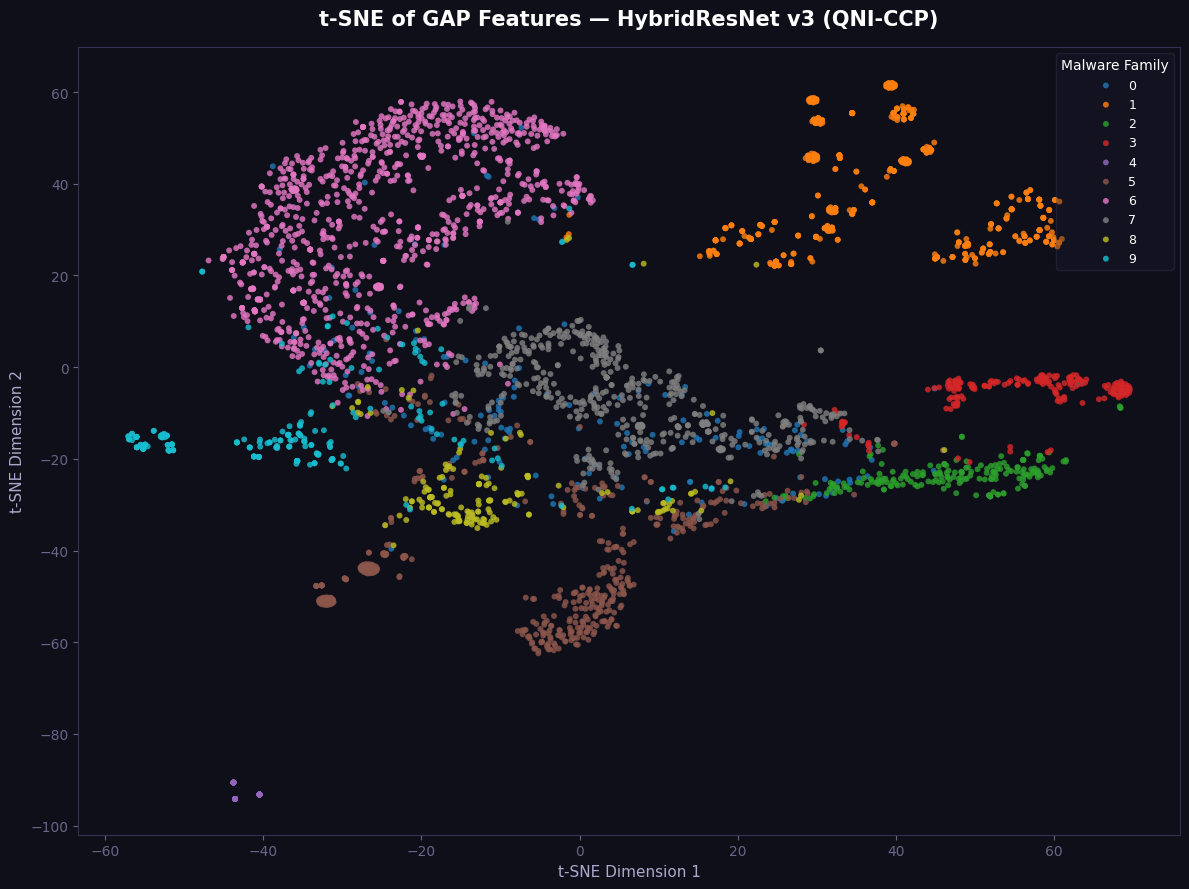

  t-SNE plot saved → tsne_qni_model.png


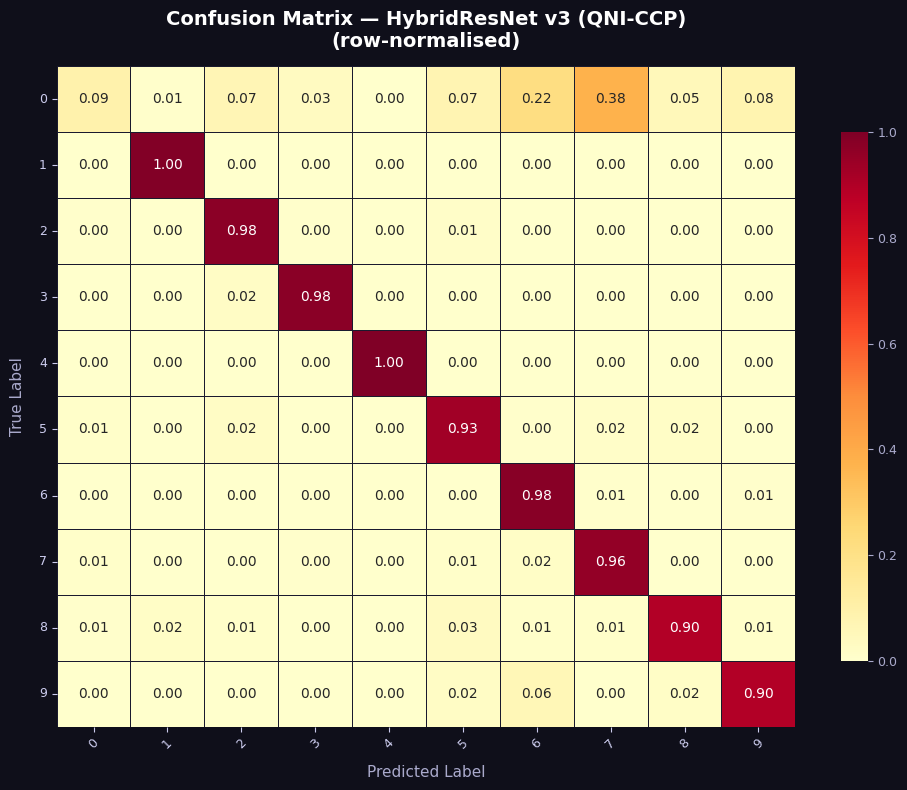

  Confusion matrix saved → confusion_matrix_qni_model.png


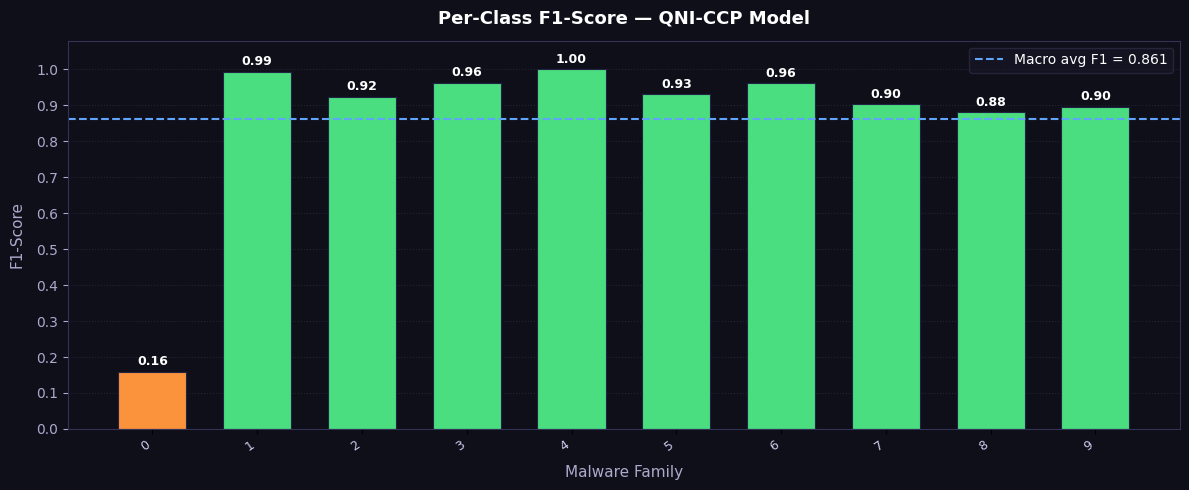

  Per-class F1 bar chart saved → per_class_f1_qni_model.png

EVALUATION SUMMARY

  Model           : HybridResNet v3 — QNI-CCP trained
  Checkpoint      : hybrid_resnet_v3_qni_only.pth  (epoch 56)
  Test samples    : 3458
  Classes         : 10

  ── Accuracy ──────────────────────────────────────
  Clean accuracy         : 0.9196 (91.96%)
  QNI-CCP robustness     : 0.9268 (92.68%)
  Robustness drop        : -0.72 pp

  ── Classification ────────────────────────────────
  Macro F1               : 0.8610
  Weighted F1            : 0.9031
  Macro Precision        : 0.8892
  Macro Recall           : 0.8709

  ── Latent-Space ──────────────────────────────────
  Entropy (avg)          : 0.1390
  Feature Variance       : 0.2042
  Avg Confidence         : 0.9552
  High-conf patterns     : 88.0%

  ── Saved Plots ───────────────────────────────────
  t-SNE             → tsne_qni_model.png
  Confusion matrix  → confusion_matrix_qni_model.png
  Per-class F1      → per_class_f1_qni_model.png



In [5]:
# in depth evaluation

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import transforms
from torchvision.datasets import ImageFolder
from sklearn.manifold import TSNE                        # dimensionality reduction for t-SNE plot
from sklearn.metrics import (
    classification_report,                               # per-class precision/recall/f1
    confusion_matrix,                                    # class-wise prediction errors
    accuracy_score                                       # overall accuracy
)
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches                    # for custom legend entries
import seaborn as sns                                    # for confusion matrix heatmap
import pennylane as qml
from pennylane.qnn import TorchLayer
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')


# ══════════════════════════════════════════════════════════════════════════════
# EVALUATION SCRIPT — HybridResNet v3 QNI-CCP Model
#
# WHAT THIS SCRIPT PRODUCES:
#   1. Classification Report  — per-class precision, recall, F1, support
#   2. t-SNE Plot (2D)        — visualise how the 64-dim GAP features cluster
#                               by malware family in 2D space
#   3. Confusion Matrix       — heatmap showing where the model confuses classes
#   4. Summary metrics table  — clean accuracy + QNI-CCP robustness accuracy
#
# HOW t-SNE WORKS HERE:
#   We extract the 64-dim GAP feature vector (z) for every test image.
#   t-SNE reduces these 64 dims → 2 dims while preserving neighbourhood
#   structure: samples with similar features end up close together in 2D.
#   Well-separated, compact clusters → the model has learned discriminative
#   features per malware family. This is Figure 4 from the paper.
#
# HOW TO READ THE CLASSIFICATION REPORT:
#   precision = TP / (TP + FP)  — when model predicts class X, how often correct?
#   recall    = TP / (TP + FN)  — of all actual class X samples, how many found?
#   f1-score  = harmonic mean of precision and recall
#   support   = number of test samples for that class
#   macro avg = unweighted mean across classes (treats all classes equally)
#   weighted  = mean weighted by support (accounts for class imbalance)
# ══════════════════════════════════════════════════════════════════════════════


# ─────────────────────────────────────────────
# SEEDING
# ─────────────────────────────────────────────
def seed_all(seed=42):
    torch.manual_seed(seed)
    np.random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

seed_all(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


# ─────────────────────────────────────────────
# CONFIG — must match training exactly
# ─────────────────────────────────────────────
n_qubits    = 8
q_depth     = 6
q_out_dim   = 3 * n_qubits    # 24
num_classes = 10
batch_size  = 32              # can increase for faster eval (no gradient needed)

CHECKPOINT_PATH = "hybrid_resnet_v3_qni_only.pth"   # your saved QNI-CCP model
EPSILON_Q       = 1.0                                 # same as training


# ─────────────────────────────────────────────
# TRANSFORMS — identical to training eval_transform
# ─────────────────────────────────────────────
eval_transform = transforms.Compose([
    transforms.Grayscale(1),             # single-channel grayscale
    transforms.Resize((32, 32)),         # resize to model input size
    transforms.ToTensor(),               # convert to float tensor [0,1]
    transforms.Normalize((0.5,), (0.5,)) # normalise to [-1, 1]
])


# ─────────────────────────────────────────────
# DATASETS — test set only for evaluation
# Also loading train set for centroid computation
# ─────────────────────────────────────────────
TRAIN_PATH = 'virus_MNIST dataset/train_balanced_v2'
TEST_PATH  = 'virus_MNIST dataset/test'

try:
    train_dataset = ImageFolder(TRAIN_PATH, transform=eval_transform)
    test_dataset  = ImageFolder(TEST_PATH,  transform=eval_transform)
    print(f"Test samples : {len(test_dataset)}")
    print(f"Train samples: {len(train_dataset)} (used only for centroid computation)")

    # class_names: list of folder names = malware family names
    # e.g. ['Adware', 'Backdoor', 'Ransomware', ...]
    class_names = test_dataset.classes
    print(f"Classes ({num_classes}): {class_names}")
except Exception as e:
    print(f"Dataset load error: {e}")
    raise

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False,
                          num_workers=4, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False,
                          num_workers=4, pin_memory=True)


# ══════════════════════════════════════════════════════════════════════════════
# MODEL DEFINITION — byte-for-byte identical to training script
# Must match exactly or load_state_dict() will fail with key mismatches
# ══════════════════════════════════════════════════════════════════════════════

dev_qml = qml.device("default.qubit", wires=n_qubits)   # PennyLane device

@qml.qnode(dev_qml, interface="torch", diff_method="backprop")
def quantum_circuit(inputs, weights):
    # Angle encoding: 16 bridge values → RY/RZ rotations on 8 qubits
    for i in range(n_qubits):
        qml.RY(inputs[..., i],            wires=i)   # first 8 → RY
        qml.RZ(inputs[..., i + n_qubits], wires=i)   # next  8 → RZ
    # Alternating brick entanglement + re-uploading per layer
    for l in range(weights.shape[0]):
        if l % 2 == 0:
            for i in range(0, n_qubits - 1, 2):
                qml.CRZ(weights[l, i, 2], wires=[i, i + 1])
        else:
            for i in range(1, n_qubits - 1, 2):
                qml.CRZ(weights[l, i, 2], wires=[i, i + 1])
        for i in range(n_qubits):
            qml.RY(weights[l, i, 0] + inputs[..., i],            wires=i)
            qml.RZ(weights[l, i, 1] + inputs[..., i + n_qubits], wires=i)
    # 3-axis Pauli measurements → 24 expectation values ∈ [-1,1]
    measurements = []
    for i in range(n_qubits):
        measurements.append(qml.expval(qml.PauliZ(i)))
        measurements.append(qml.expval(qml.PauliX(i)))
        measurements.append(qml.expval(qml.PauliY(i)))
    return measurements

weight_shapes = {"weights": (q_depth, n_qubits, 3)}


class SEBlock(nn.Module):
    """Channel attention: (B,C,H,W) → GAP → FC → Sigmoid → channel rescale"""
    def __init__(self, channels, reduction=4):
        super().__init__()
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.fc   = nn.Sequential(
            nn.Linear(channels, max(channels // reduction, 4), bias=False),
            nn.ReLU(),
            nn.Linear(max(channels // reduction, 4), channels, bias=False),
            nn.Sigmoid()
        )
    def forward(self, x):
        b, c, _, _ = x.shape
        s = self.pool(x).view(b, c)
        return x * self.fc(s).view(b, c, 1, 1)


class ResBlock(nn.Module):
    """Residual block with SE attention + stochastic depth"""
    def __init__(self, in_ch, out_ch, stride=1, dropout=0.20, drop_path=0.10):
        super().__init__()
        self.conv_block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, stride=stride, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            nn.Dropout2d(dropout),
            nn.Conv2d(out_ch, out_ch, 3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(out_ch)
        )
        self.se             = SEBlock(out_ch)
        self.drop_path_rate = drop_path
        self.skip = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 1, stride=stride, bias=False),
            nn.BatchNorm2d(out_ch)
        ) if (stride != 1 or in_ch != out_ch) else nn.Identity()
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        out = self.se(self.conv_block(x))
        if self.training and self.drop_path_rate > 0:
            keep = 1 - self.drop_path_rate
            mask = (torch.rand(x.shape[0], 1, 1, 1, device=x.device) < keep).float()
            out  = out * mask / keep
        return self.relu(out + self.skip(x))


class QuantumBridge(nn.Module):
    """Compress 64-dim backbone features → 16 quantum angles: (B,64)→(B,16)"""
    def __init__(self, in_features, n_qubits):
        super().__init__()
        self.project = nn.Sequential(
            nn.Linear(in_features, 32), nn.LayerNorm(32),
            nn.GELU(), nn.Dropout(0.35), nn.Linear(32, n_qubits * 2)
        )
        self.angle_scale = nn.Parameter(torch.ones(n_qubits * 2) * torch.pi)
        self.angle_bias  = nn.Parameter(torch.zeros(n_qubits * 2))

    def forward(self, x):
        return self.angle_scale * torch.sigmoid(self.project(x)) + self.angle_bias


class HybridResNet(nn.Module):
    """
    HybridResNet v3: (B,1,32,32) → backbone → GAP(B,64) → bridge → q_layer → classifier(B,10)
    GAP output (B,64) is the feature space visualised by t-SNE.
    """
    def __init__(self, n_qubits, q_out_dim, num_classes, dropout=0.35):
        super().__init__()
        self.stem   = nn.Sequential(
            nn.Conv2d(1, 16, 3, 1, 1, bias=False), nn.BatchNorm2d(16), nn.ReLU(inplace=True)
        )
        self.stage1 = nn.Sequential(ResBlock(16,16,drop_path=0.10), ResBlock(16,16,drop_path=0.10))
        self.stage2 = nn.Sequential(ResBlock(16,32,stride=2,drop_path=0.15), ResBlock(32,32,drop_path=0.15))
        self.stage3 = nn.Sequential(ResBlock(32,64,stride=2,drop_path=0.20), ResBlock(64,64,drop_path=0.20))
        self.gap        = nn.AdaptiveAvgPool2d(1)   # ← t-SNE features extracted here
        self.bridge     = QuantumBridge(64, n_qubits)
        self.q_layer    = TorchLayer(quantum_circuit, weight_shapes)
        self.classifier = nn.Sequential(
            nn.Linear(q_out_dim, q_out_dim*2), nn.ReLU(inplace=True),
            nn.Dropout(dropout), nn.Linear(q_out_dim*2, num_classes)
        )
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, (nn.BatchNorm2d, nn.LayerNorm)):
                nn.init.ones_(m.weight); nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight)
                if m.bias is not None: nn.init.zeros_(m.bias)

    def forward(self, x):
        x = self.stem(x); x = self.stage1(x)
        x = self.stage2(x); x = self.stage3(x)
        x = self.gap(x)                   # (B,64,1,1)
        x = x.view(x.size(0), -1)         # (B,64) ← latent space
        x = self.bridge(x)                # (B,16)
        x = self.q_layer(x)               # (B,24)
        return self.classifier(x)         # (B,10)


# ══════════════════════════════════════════════════════════════════════════════
# FEATURE EXTRACTION UTILITIES
# ══════════════════════════════════════════════════════════════════════════════

class FeatureHook:
    """
    Attaches to model.gap and captures (B,64,1,1) output automatically
    on every forward call. Call remove() when done to free memory.
    """
    def __init__(self, layer):
        self.features = None
        self._handle  = layer.register_forward_hook(self._capture)
    def _capture(self, module, inp, output):
        self.features = output
    def remove(self):
        self._handle.remove()


def extract_features_and_predictions(model, dataloader, device):
    """
    Single pass over the dataloader.
    Returns:
      all_features  : (N, 64) numpy array — GAP latent vectors for t-SNE
      all_labels    : (N,)    numpy array — true class indices
      all_preds     : (N,)    numpy array — predicted class indices
      all_probs     : (N, C)  numpy array — softmax probabilities (for confidence)

    Why one pass collects everything:
      The FeatureHook fires during model(x), giving us z (B,64).
      Simultaneously, model(x) returns logits → argmax → predictions.
      This avoids running the forward pass twice.
    """
    model.eval()
    all_features, all_labels, all_preds, all_probs = [], [], [], []

    hook = FeatureHook(model.gap)    # register hook on GAP layer once

    with torch.no_grad():            # no gradient needed for evaluation
        for x, y in tqdm(dataloader, desc="Extracting features", leave=False):
            x, y    = x.to(device), y.to(device)
            logits  = model(x)       # (B,10) — hook also fires, capturing (B,64,1,1)

            # gather GAP features from hook
            z = hook.features.view(hook.features.size(0), -1)   # (B,64,1,1) → (B,64)
            all_features.append(z.cpu().numpy())

            probs = F.softmax(logits, dim=1)                     # (B,10) probabilities
            preds = logits.argmax(dim=1)                         # (B,) predicted class

            all_labels.append(y.cpu().numpy())
            all_preds.append(preds.cpu().numpy())
            all_probs.append(probs.cpu().numpy())

    hook.remove()    # deregister hook to prevent memory leak

    return (
        np.concatenate(all_features, axis=0),   # (N, 64)
        np.concatenate(all_labels,   axis=0),   # (N,)
        np.concatenate(all_preds,    axis=0),   # (N,)
        np.concatenate(all_probs,    axis=0)    # (N, C)
    )


def compute_class_centroids(model, dataloader, device, num_classes):
    """
    Computes mean GAP feature (centroid) per class over the training set.
    Used for QNI robustness evaluation.
    Returns: (num_classes, 64) tensor
    """
    model.eval()
    hook         = FeatureHook(model.gap)
    sum_features = torch.zeros(num_classes, 64, device=device)
    count        = torch.zeros(num_classes,     device=device)

    with torch.no_grad():
        for x, y in tqdm(dataloader, desc="Computing centroids", leave=False):
            x, y = x.to(device), y.to(device)
            _    = model(x)          # fires hook
            z    = hook.features.view(hook.features.size(0), -1)   # (B,64)
            for c in range(num_classes):
                mask = (y == c)
                if mask.sum() > 0:
                    sum_features[c] += z[mask].sum(dim=0)
                    count[c]        += mask.sum()

    hook.remove()
    return sum_features / count.clamp(min=1.0).unsqueeze(1)   # (num_classes, 64)


def evaluate_qni_robustness(model, dataloader, device, centroids, epsilon_q=1.0):
    """
    Measures accuracy when GAP features are perturbed by QNI-CCP attack.
    This is the adversarial robustness metric — how much does accuracy drop?

    Data flow:
      x → full forward (get z) → compute sensitivity → perturb z toward
      wrong centroid → bridge→q_layer→classifier → accuracy
    Returns: robustness accuracy (float)
    """
    model.eval()
    correct, total = 0, 0

    for x, y in tqdm(dataloader, desc="QNI Robustness Eval", leave=False):
        x, y = x.to(device), y.to(device)

        # Extract z with gradient for sensitivity computation
        hook  = FeatureHook(model.gap)
        _     = model(x)
        z_raw = hook.features.view(hook.features.size(0), -1)
        hook.remove()

        z = z_raw.detach().requires_grad_(True)   # enable grad on z only
        logits = model.classifier(model.q_layer(model.bridge(z)))
        F.cross_entropy(logits, y).backward()     # fills z.grad with sensitivity

        S_norm = z.grad.detach()
        S_norm = S_norm / (S_norm.norm(dim=1, keepdim=True) + 1e-8)   # L2-normalise

        z_det = z.detach()
        wrong = [np.random.choice([c for c in range(centroids.size(0)) if c != yi.item()])
                 for yi in y]
        mu_wrong    = centroids[torch.tensor(wrong, device=device)]   # (B,64)
        z_perturbed = z_det + epsilon_q * (S_norm * (mu_wrong - z_det))

        with torch.no_grad():
            logits_p = model.classifier(model.q_layer(model.bridge(z_perturbed)))
            correct += (logits_p.argmax(1) == y).sum().item()
            total   += y.size(0)

    return correct / total


# ══════════════════════════════════════════════════════════════════════════════
# PLOTTING FUNCTIONS
# ══════════════════════════════════════════════════════════════════════════════

def plot_tsne(features, labels, class_names, title="t-SNE of GAP Features",
              save_path="tsne_qni_model.png"):
    """
    Runs t-SNE on (N, 64) GAP features and plots 2D scatter.

    t-SNE parameters:
      n_components=2    : reduce to 2D for plotting
      perplexity=40     : roughly the number of close neighbours each point
                          considers. 30-50 works well for hundreds of samples.
                          Too low → tight blobs; too high → spread-out clouds.
      n_iter=1000       : number of optimisation steps (more = better quality)
      random_state=42   : reproducible layout
      learning_rate=200 : step size for t-SNE gradient descent

    Each dot = one test image. Colour = true malware family.
    Well-separated clusters → model learned discriminative features.
    Overlapping clusters → model confuses those families.
    """
    print("\nRunning t-SNE dimensionality reduction...")
    print(f"  Input shape  : {features.shape}  (N samples × 64 features)")

    tsne = TSNE(
        n_components=2,    # reduce to 2D for visualisation
        perplexity=40,     # neighbourhood size — 30-50 is standard
        n_iter=1000,       # optimisation iterations
        random_state=42,   # reproducible
        learning_rate=200, # gradient step size
        init='pca'         # PCA initialisation → more stable than random
    )
    embedded = tsne.fit_transform(features)   # (N, 64) → (N, 2)
    print(f"  Output shape : {embedded.shape}  (N samples × 2 t-SNE dimensions)")

    # ── Colour palette: one distinct colour per class ──────────────────────
    # Using tab10 for up to 10 classes (matches Matplotlib's default cycle)
    palette = plt.cm.get_cmap('tab10', num_classes)
    colors  = [palette(i) for i in range(num_classes)]   # list of RGBA tuples

    # ── Plot ───────────────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(12, 9))
    fig.patch.set_facecolor('#0f0f1a')   # dark background — matches paper style
    ax.set_facecolor('#0f0f1a')

    for cls_idx in range(num_classes):
        mask = (labels == cls_idx)                      # boolean mask for this class
        ax.scatter(
            embedded[mask, 0],                          # t-SNE dim 1 (x-axis)
            embedded[mask, 1],                          # t-SNE dim 2 (y-axis)
            c=[colors[cls_idx]],                        # class colour
            label=class_names[cls_idx],                 # for legend
            s=18,                                       # marker size
            alpha=0.82,                                 # slight transparency
            edgecolors='none'                           # no border on dots
        )

    # ── Styling ────────────────────────────────────────────────────────────
    ax.set_title(title, fontsize=15, fontweight='bold',
                 color='white', pad=16)
    ax.set_xlabel("t-SNE Dimension 1", fontsize=11, color='#aaaacc')
    ax.set_ylabel("t-SNE Dimension 2", fontsize=11, color='#aaaacc')
    ax.tick_params(colors='#666688')
    for spine in ax.spines.values():
        spine.set_edgecolor('#333355')

    legend = ax.legend(
        title="Malware Family", title_fontsize=10,
        fontsize=9, loc='upper right',
        framealpha=0.3, facecolor='#1a1a2e', edgecolor='#444466',
        labelcolor='white'
    )
    legend.get_title().set_color('white')

    plt.tight_layout()
    plt.savefig(save_path, dpi=180, bbox_inches='tight',
                facecolor=fig.get_facecolor())
    plt.show()
    print(f"  t-SNE plot saved → {save_path}")
    return embedded   # return for potential further analysis


def plot_confusion_matrix(y_true, y_pred, class_names,
                          title="Confusion Matrix",
                          save_path="confusion_matrix_qni_model.png"):
    """
    Plots a normalised confusion matrix as a heatmap.

    normalise=True → each row sums to 1.0 (shows proportion, not raw count)
    This lets you see which classes are confused even if class sizes differ.

    Row   = true label  (what the sample actually is)
    Column = predicted label (what the model said it was)
    Diagonal = correct predictions (want these high)
    Off-diagonal = errors (want these near 0)

    Colour: dark blue = low fraction, bright yellow = high fraction.
    """
    cm = confusion_matrix(y_true, y_pred)                        # raw counts (C, C)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)  # normalise each row to [0,1]

    fig, ax = plt.subplots(figsize=(10, 8))
    fig.patch.set_facecolor('#0f0f1a')
    ax.set_facecolor('#0f0f1a')

    sns.heatmap(
        cm_norm,
        annot=True,                   # write numbers inside each cell
        fmt='.2f',                    # 2 decimal places
        cmap='YlOrRd',                # yellow→red colour scale (paper-like)
        xticklabels=class_names,      # column labels = predicted class
        yticklabels=class_names,      # row labels    = true class
        ax=ax,
        linewidths=0.5,
        linecolor='#1a1a2e',
        cbar_kws={'shrink': 0.8}
    )

    ax.set_title(title, fontsize=14, fontweight='bold', color='white', pad=14)
    ax.set_xlabel("Predicted Label", fontsize=11, color='#aaaacc', labelpad=10)
    ax.set_ylabel("True Label",      fontsize=11, color='#aaaacc', labelpad=10)
    ax.tick_params(axis='x', colors='#ccccee', labelsize=9, rotation=45)
    ax.tick_params(axis='y', colors='#ccccee', labelsize=9, rotation=0)

    # Style the colour bar
    cbar = ax.collections[0].colorbar
    cbar.ax.yaxis.set_tick_params(color='#aaaacc')
    cbar.ax.tick_params(labelsize=9, colors='#aaaacc')

    plt.tight_layout()
    plt.savefig(save_path, dpi=180, bbox_inches='tight',
                facecolor=fig.get_facecolor())
    plt.show()
    print(f"  Confusion matrix saved → {save_path}")


def plot_per_class_f1(report_dict, class_names,
                      save_path="per_class_f1_qni_model.png"):
    """
    Bar chart of per-class F1-score.
    Makes it easy to spot which malware families are hardest to classify.
    Dashed line = macro average F1 across all classes.
    """
    f1_scores = [report_dict[cls]['f1-score'] for cls in class_names]   # one F1 per class
    macro_f1  = report_dict['macro avg']['f1-score']                     # average F1

    fig, ax = plt.subplots(figsize=(12, 5))
    fig.patch.set_facecolor('#0f0f1a')
    ax.set_facecolor('#0f0f1a')

    # Colour bars: green if above macro avg, orange if below
    bar_colors = ['#4ade80' if f >= macro_f1 else '#fb923c' for f in f1_scores]
    bars = ax.bar(range(num_classes), f1_scores, color=bar_colors,
                  edgecolor='#222244', linewidth=0.8, width=0.65)

    # Value labels on top of bars
    for bar, val in zip(bars, f1_scores):
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
                f'{val:.2f}', ha='center', va='bottom',
                fontsize=9, color='white', fontweight='bold')

    # Macro avg reference line
    ax.axhline(y=macro_f1, color='#60a5fa', linestyle='--', linewidth=1.5,
               label=f'Macro avg F1 = {macro_f1:.3f}')

    ax.set_xticks(range(num_classes))
    ax.set_xticklabels(class_names, rotation=35, ha='right',
                       fontsize=9, color='#ccccee')
    ax.set_yticks(np.arange(0, 1.05, 0.1))
    ax.tick_params(axis='y', colors='#aaaacc')
    ax.set_ylim(0, 1.08)
    ax.set_xlabel("Malware Family", fontsize=11, color='#aaaacc', labelpad=8)
    ax.set_ylabel("F1-Score",       fontsize=11, color='#aaaacc', labelpad=8)
    ax.set_title("Per-Class F1-Score — QNI-CCP Model",
                 fontsize=13, fontweight='bold', color='white', pad=12)
    ax.legend(fontsize=10, labelcolor='white', facecolor='#1a1a2e',
              edgecolor='#444466', framealpha=0.4)

    # Grid for readability
    ax.yaxis.grid(True, linestyle=':', alpha=0.3, color='#555577')
    ax.set_axisbelow(True)
    for spine in ax.spines.values():
        spine.set_edgecolor('#333355')

    plt.tight_layout()
    plt.savefig(save_path, dpi=180, bbox_inches='tight',
                facecolor=fig.get_facecolor())
    plt.show()
    print(f"  Per-class F1 bar chart saved → {save_path}")


# ══════════════════════════════════════════════════════════════════════════════
# MAIN EVALUATION
# ══════════════════════════════════════════════════════════════════════════════

# ── Step 1: Build model and load checkpoint ───────────────────────────────────
model = HybridResNet(
    n_qubits    = n_qubits,
    q_out_dim   = q_out_dim,
    num_classes = num_classes,
    dropout     = 0.35
).to(device)

print(f"\nLoading checkpoint: {CHECKPOINT_PATH}")
checkpoint = torch.load(CHECKPOINT_PATH, map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])   # restore all trained weights

saved_epoch   = checkpoint.get('epoch', '?')
saved_val_acc = checkpoint.get('val_acc', '?')
print(f"  Checkpoint from epoch : {saved_epoch}")
print(f"  Saved val accuracy    : {saved_val_acc:.4f}" if isinstance(saved_val_acc, float)
      else f"  Saved val accuracy    : {saved_val_acc}")
print(f"  Training type         : {checkpoint.get('config', {}).get('training', 'QNI-CCP_only')}")

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"  Total parameters      : {total_params:,}")

# ── Step 2: Extract features + predictions in one forward pass ────────────────
print("\n" + "="*65)
print("STEP 1/4 — FEATURE EXTRACTION")
print("="*65)

features, true_labels, pred_labels, pred_probs = \
    extract_features_and_predictions(model, test_loader, device)

# features     : (N, 64) — what t-SNE will visualise
# true_labels  : (N,)    — ground truth class indices
# pred_labels  : (N,)    — model predictions
# pred_probs   : (N, C)  — confidence per class

print(f"\n  Samples extracted : {len(true_labels)}")
print(f"  Feature dimension : {features.shape[1]}  (GAP output before bridge)")


# ── Step 3: Classification Report ─────────────────────────────────────────────
print("\n" + "="*65)
print("STEP 2/4 — CLASSIFICATION REPORT")
print("="*65)

overall_acc = accuracy_score(true_labels, pred_labels)   # fraction correctly classified
print(f"\n  Clean Test Accuracy : {overall_acc:.4f}  ({overall_acc*100:.2f}%)\n")

# classification_report: per-class P / R / F1 + macro/weighted averages
# output_dict=True → returns dict so we can also use values programmatically
report_str  = classification_report(
    true_labels, pred_labels,
    target_names = class_names,   # use folder names as class labels
    digits       = 4              # 4 decimal places
)
report_dict = classification_report(
    true_labels, pred_labels,
    target_names = class_names,
    digits       = 4,
    output_dict  = True           # also return as dict for programmatic use
)
print(report_str)

# ── Step 4: Compute QNI robustness ────────────────────────────────────────────
print("\n" + "="*65)
print("STEP 3/4 — QNI-CCP ROBUSTNESS EVALUATION")
print("="*65)

print("\nComputing training-set centroids for QNI perturbation...")
centroids = compute_class_centroids(model, train_loader, device, num_classes)
# centroids: (10, 64) — mean GAP feature vector per malware family

print("\nApplying QNI-CCP attack on test set...")
qni_acc = evaluate_qni_robustness(model, test_loader, device, centroids, EPSILON_Q)

print(f"\n  Clean Test Accuracy         : {overall_acc:.4f}  ({overall_acc*100:.2f}%)")
print(f"  Under QNI-CCP Perturbation  : {qni_acc:.4f}  ({qni_acc*100:.2f}%)")
print(f"  Robustness drop             : {(overall_acc - qni_acc)*100:.2f} pp")
# pp = percentage points — absolute difference in accuracy

# ── Step 5: Additional latent-space metrics (Table 6 from paper) ──────────────
print("\n" + "="*65)
print("STEP 4/4 — LATENT-SPACE METRICS (Table 6 style)")
print("="*65)

# Entropy: measures how evenly the model distributes probability across classes
# High entropy → uncertain/flat predictions; Low entropy → confident predictions
# Computed per sample as: H = -Σ p_i * log(p_i), then averaged
eps         = 1e-9                                           # avoid log(0)
entropy     = -np.sum(pred_probs * np.log(pred_probs + eps), axis=1)   # (N,) per sample
mean_entropy = entropy.mean()                                # scalar — avg uncertainty

# Feature Variance: spread of activation values across the 64-dim feature space
# Low variance → compact, uniform features (paper: QNNs have lower variance)
feature_variance = features.var(axis=0).mean()   # mean variance across 64 dims

# Unique Patterns: distinct activation patterns (rounded to 1 decimal)
# Proxy for how many distinct "modes" the feature extractor produces
unique_patterns = len(np.unique(np.round(features, 1), axis=0))

# Average Confidence: mean probability assigned to the predicted class
# High confidence → model is certain; should correlate with accuracy
max_probs        = pred_probs.max(axis=1)           # (N,) — confidence per sample
avg_confidence   = max_probs.mean()                  # scalar
conf_std         = max_probs.std()                   # scalar — consistency of confidence

# High-confidence patterns: fraction of samples where confidence > 0.90
high_conf_frac = (max_probs >= 0.90).mean() * 100   # as percentage

print(f"\n  {'Metric':<35} {'Value':>10}")
print(f"  {'-'*45}")
print(f"  {'Entropy (avg prediction entropy)':<35} {mean_entropy:>10.4f}")
print(f"  {'Feature Variance (avg across dims)':<35} {feature_variance:>10.4f}")
print(f"  {'Unique Patterns':<35} {unique_patterns:>10d}")
print(f"  {'High-confidence patterns (≥90%)':<35} {high_conf_frac:>9.1f}%")
print(f"  {'Average confidence':<35} {avg_confidence:>10.4f}")
print(f"  {'Confidence std dev':<35} {conf_std:>10.4f}")


# ── Step 6: Generate all plots ────────────────────────────────────────────────
print("\n" + "="*65)
print("GENERATING PLOTS")
print("="*65)

# t-SNE: visualise 64-dim features in 2D
# Each dot = one test sample, colour = true malware family
# Compact separated clusters → good feature learning
tsne_emb = plot_tsne(
    features, true_labels, class_names,
    title     = "t-SNE of GAP Features — HybridResNet v3 (QNI-CCP)",
    save_path = "tsne_qni_model.png"
)

# Confusion matrix: (C×C) heatmap of normalised predictions
# Bright diagonal → correct; off-diagonal bright cells → systematic confusions
plot_confusion_matrix(
    true_labels, pred_labels, class_names,
    title     = "Confusion Matrix — HybridResNet v3 (QNI-CCP)\n(row-normalised)",
    save_path = "confusion_matrix_qni_model.png"
)

# Per-class F1 bar chart: spot which families are hardest
plot_per_class_f1(
    report_dict, class_names,
    save_path = "per_class_f1_qni_model.png"
)


# ── Final summary ─────────────────────────────────────────────────────────────
print("\n" + "="*65)
print("EVALUATION SUMMARY")
print("="*65)
print(f"""
  Model           : HybridResNet v3 — QNI-CCP trained
  Checkpoint      : {CHECKPOINT_PATH}  (epoch {saved_epoch})
  Test samples    : {len(true_labels)}
  Classes         : {num_classes}

  ── Accuracy ──────────────────────────────────────
  Clean accuracy         : {overall_acc:.4f} ({overall_acc*100:.2f}%)
  QNI-CCP robustness     : {qni_acc:.4f} ({qni_acc*100:.2f}%)
  Robustness drop        : {(overall_acc-qni_acc)*100:.2f} pp

  ── Classification ────────────────────────────────
  Macro F1               : {report_dict['macro avg']['f1-score']:.4f}
  Weighted F1            : {report_dict['weighted avg']['f1-score']:.4f}
  Macro Precision        : {report_dict['macro avg']['precision']:.4f}
  Macro Recall           : {report_dict['macro avg']['recall']:.4f}

  ── Latent-Space ──────────────────────────────────
  Entropy (avg)          : {mean_entropy:.4f}
  Feature Variance       : {feature_variance:.4f}
  Avg Confidence         : {avg_confidence:.4f}
  High-conf patterns     : {high_conf_frac:.1f}%

  ── Saved Plots ───────────────────────────────────
  t-SNE             → tsne_qni_model.png
  Confusion matrix  → confusion_matrix_qni_model.png
  Per-class F1      → per_class_f1_qni_model.png
""")

In [ ]:
'''
similar testing as we did in previous dataset

'''

In [6]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import transforms
from torchvision.datasets import ImageFolder
from sklearn.manifold import TSNE
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score
)
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import pennylane as qml
from pennylane.qnn import TorchLayer
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# ══════════════════════════════════════════════════════════════════════════════
# FAIR COMPARISON EVALUATION — Clean Baseline vs QNI-CCP Model
#
# GUARANTEE OF FAIRNESS:
#   Both models go through EXACTLY the same code path:
#     • Same test set, same DataLoader, same batch size
#     • Same FeatureHook on model.gap → same 64-dim feature space
#     • Same t-SNE params (perplexity, n_iter, random_state, init)
#     • Same TSNE random_state=42 — layout is comparable between plots
#     • Same epsilon (EPSILON_Q=1.0) for QNI robustness test
#     • Same classification_report call → same metric definitions
#     • Same confusion matrix normalisation (row-normalised)
#     • Same latent-space metric formulas (entropy, variance, etc.)
#
# WHAT IS PRODUCED:
#   Individual per-model outputs (saved separately):
#     clean_tsne.png                    — t-SNE of clean model features
#     qni_tsne.png                      — t-SNE of QNI-CCP model features
#     clean_confusion_matrix.png        — confusion matrix for clean model
#     qni_confusion_matrix.png          — confusion matrix for QNI-CCP model
#     clean_per_class_f1.png            — per-class F1 bar chart, clean model
#     qni_per_class_f1.png              — per-class F1 bar chart, QNI model
#
#   Side-by-side comparison plots (the important ones):
#     comparison_tsne.png               — both t-SNEs on one figure (like Fig 4)
#     comparison_confusion_matrix.png   — both confusion matrices side by side
#     comparison_per_class_f1.png       — overlaid F1 bars for direct comparison
#     comparison_latent_metrics.png     — Table 6 style bar chart
#
#   Console output:
#     Full classification report for each model
#     Table 6 style latent-space metrics for both models side by side
#     Summary comparison table
# ══════════════════════════════════════════════════════════════════════════════


# ─────────────────────────────────────────────
# SEEDING — must be 42 everywhere for reproducibility
# ─────────────────────────────────────────────
def seed_all(seed=42):
    torch.manual_seed(seed)       # PyTorch CPU
    np.random.seed(seed)          # NumPy
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)   # all GPUs

seed_all(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")


# ─────────────────────────────────────────────
# ══ ONLY CHANGE THESE TWO LINES ══
# Set both checkpoint paths to evaluate your two models
# ─────────────────────────────────────────────
CLEAN_CHECKPOINT = "hybrid_resnet_NOGAN.pth"         # clean baseline (no QNI-CCP)
QNI_CHECKPOINT   = "hybrid_resnet_v3_qni_only.pth"   # QNI-CCP trained model

# Labels used in all plots and tables
CLEAN_LABEL = "Clean Baseline"
QNI_LABEL   = "QNI-CCP Trained"


# ─────────────────────────────────────────────
# CONFIG — identical to both training scripts
# ─────────────────────────────────────────────
n_qubits    = 8
q_depth     = 6
q_out_dim   = 3 * n_qubits   # 24
num_classes = 10
batch_size  = 32              # same batch size → same forward pass behaviour
EPSILON_Q   = 1.0             # QNI-CCP perturbation strength (paper value)


# ─────────────────────────────────────────────
# TRANSFORMS — identical to eval_transform in both training scripts
# ─────────────────────────────────────────────
eval_transform = transforms.Compose([
    transforms.Grayscale(1),              # single channel
    transforms.Resize((32, 32)),          # 32×32 — model input size
    transforms.ToTensor(),                # float tensor [0,1]
    transforms.Normalize((0.5,), (0.5,)) # normalise to [-1,1]
])


# ─────────────────────────────────────────────
# DATASETS — both models evaluated on the same test set
# ─────────────────────────────────────────────
TRAIN_PATH = 'virus_MNIST dataset/train_balanced_v2'
TEST_PATH  = 'virus_MNIST dataset/test'

try:
    train_dataset = ImageFolder(TRAIN_PATH, transform=eval_transform)
    test_dataset  = ImageFolder(TEST_PATH,  transform=eval_transform)
    class_names   = test_dataset.classes   # malware family folder names
    print(f"Test  samples : {len(test_dataset)}")
    print(f"Train samples : {len(train_dataset)}  (used only for centroids)")
    print(f"Classes ({num_classes}): {class_names}")
except Exception as e:
    print(f"Dataset error: {e}"); raise

# shuffle=False so both models see batches in the same order
train_loader = DataLoader(train_dataset, batch_size=batch_size,
                          shuffle=False, num_workers=4, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=batch_size,
                          shuffle=False, num_workers=4, pin_memory=True)


# ══════════════════════════════════════════════════════════════════════════════
# MODEL DEFINITION — must be byte-for-byte identical to both training scripts
# ══════════════════════════════════════════════════════════════════════════════

dev_qml = qml.device("default.qubit", wires=n_qubits)

@qml.qnode(dev_qml, interface="torch", diff_method="backprop")
def quantum_circuit(inputs, weights):
    # Angle encoding: 16 bridge outputs → RY/RZ on each of 8 qubits
    for i in range(n_qubits):
        qml.RY(inputs[..., i],            wires=i)
        qml.RZ(inputs[..., i + n_qubits], wires=i)
    # Alternating brick entanglement + data re-uploading per layer
    for l in range(weights.shape[0]):
        if l % 2 == 0:
            for i in range(0, n_qubits - 1, 2):
                qml.CRZ(weights[l, i, 2], wires=[i, i + 1])
        else:
            for i in range(1, n_qubits - 1, 2):
                qml.CRZ(weights[l, i, 2], wires=[i, i + 1])
        for i in range(n_qubits):
            qml.RY(weights[l, i, 0] + inputs[..., i],            wires=i)
            qml.RZ(weights[l, i, 1] + inputs[..., i + n_qubits], wires=i)
    # 3-axis Pauli measurements → 24 expectation values
    measurements = []
    for i in range(n_qubits):
        measurements.append(qml.expval(qml.PauliZ(i)))
        measurements.append(qml.expval(qml.PauliX(i)))
        measurements.append(qml.expval(qml.PauliY(i)))
    return measurements

weight_shapes = {"weights": (q_depth, n_qubits, 3)}


class SEBlock(nn.Module):
    def __init__(self, channels, reduction=4):
        super().__init__()
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.fc   = nn.Sequential(
            nn.Linear(channels, max(channels // reduction, 4), bias=False),
            nn.ReLU(),
            nn.Linear(max(channels // reduction, 4), channels, bias=False),
            nn.Sigmoid()
        )
    def forward(self, x):
        b, c = x.shape[:2]
        return x * self.fc(self.pool(x).view(b, c)).view(b, c, 1, 1)


class ResBlock(nn.Module):
    def __init__(self, in_ch, out_ch, stride=1, dropout=0.20, drop_path=0.10):
        super().__init__()
        self.conv_block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, stride=stride, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True), nn.Dropout2d(dropout),
            nn.Conv2d(out_ch, out_ch, 3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(out_ch)
        )
        self.se             = SEBlock(out_ch)
        self.drop_path_rate = drop_path
        self.skip = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 1, stride=stride, bias=False),
            nn.BatchNorm2d(out_ch)
        ) if (stride != 1 or in_ch != out_ch) else nn.Identity()
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        out = self.se(self.conv_block(x))
        if self.training and self.drop_path_rate > 0:
            keep = 1 - self.drop_path_rate
            mask = (torch.rand(x.shape[0], 1, 1, 1, device=x.device) < keep).float()
            out  = out * mask / keep
        return self.relu(out + self.skip(x))


class QuantumBridge(nn.Module):
    def __init__(self, in_features, n_qubits):
        super().__init__()
        self.project = nn.Sequential(
            nn.Linear(in_features, 32), nn.LayerNorm(32),
            nn.GELU(), nn.Dropout(0.35), nn.Linear(32, n_qubits * 2)
        )
        self.angle_scale = nn.Parameter(torch.ones(n_qubits * 2) * torch.pi)
        self.angle_bias  = nn.Parameter(torch.zeros(n_qubits * 2))

    def forward(self, x):
        return self.angle_scale * torch.sigmoid(self.project(x)) + self.angle_bias


class HybridResNet(nn.Module):
    """
    HybridResNet v3.
    Data flow: (B,1,32,32) → stem → stage1-3 → GAP(B,64) → bridge → q_layer → classifier(B,10)
    The GAP output (B,64) is what FeatureHook captures for t-SNE and QNI-CCP.
    """
    def __init__(self, n_qubits, q_out_dim, num_classes, dropout=0.35):
        super().__init__()
        self.stem   = nn.Sequential(
            nn.Conv2d(1, 16, 3, 1, 1, bias=False), nn.BatchNorm2d(16), nn.ReLU(inplace=True)
        )
        self.stage1 = nn.Sequential(ResBlock(16,16,drop_path=0.10), ResBlock(16,16,drop_path=0.10))
        self.stage2 = nn.Sequential(ResBlock(16,32,stride=2,drop_path=0.15), ResBlock(32,32,drop_path=0.15))
        self.stage3 = nn.Sequential(ResBlock(32,64,stride=2,drop_path=0.20), ResBlock(64,64,drop_path=0.20))
        self.gap        = nn.AdaptiveAvgPool2d(1)   # ← FeatureHook attaches HERE
        self.bridge     = QuantumBridge(64, n_qubits)
        self.q_layer    = TorchLayer(quantum_circuit, weight_shapes)
        self.classifier = nn.Sequential(
            nn.Linear(q_out_dim, q_out_dim*2), nn.ReLU(inplace=True),
            nn.Dropout(dropout), nn.Linear(q_out_dim*2, num_classes)
        )
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, (nn.BatchNorm2d, nn.LayerNorm)):
                nn.init.ones_(m.weight); nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight)
                if m.bias is not None: nn.init.zeros_(m.bias)

    def forward(self, x):
        x = self.stem(x); x = self.stage1(x)
        x = self.stage2(x); x = self.stage3(x)
        x = self.gap(x)                   # (B,64,1,1)
        x = x.view(x.size(0), -1)         # (B,64)
        x = self.bridge(x)                # (B,16)
        x = self.q_layer(x)               # (B,24)
        return self.classifier(x)         # (B,10)


# ══════════════════════════════════════════════════════════════════════════════
# SHARED UTILITIES — same function used for BOTH models
# ══════════════════════════════════════════════════════════════════════════════

class FeatureHook:
    """
    Attaches to model.gap and captures (B,64,1,1) output on every forward call.
    Identical hook used for both models — guarantees same feature space is compared.
    """
    def __init__(self, layer):
        self.features = None
        self._handle  = layer.register_forward_hook(
            lambda m, i, o: setattr(self, 'features', o)
        )
    def remove(self): self._handle.remove()


def extract_all(model, dataloader, device):
    """
    Single forward pass over the dataloader.
    Collects GAP features (64-dim), predictions, probabilities, and true labels.

    FAIRNESS NOTE: Both models call this same function with the same dataloader.
    The hook captures features from model.gap — identical layer in both models.

    Returns:
      features  : (N, 64)  — raw GAP latent vectors, used for t-SNE
      labels    : (N,)     — true class indices
      preds     : (N,)     — predicted class indices
      probs     : (N, C)   — softmax probabilities (used for confidence metrics)
    """
    model.eval()
    all_features, all_labels, all_preds, all_probs = [], [], [], []
    hook = FeatureHook(model.gap)   # register once, fires every forward call

    with torch.no_grad():
        for x, y in tqdm(dataloader, desc="  Extracting", leave=False):
            x, y   = x.to(device), y.to(device)
            logits = model(x)                                    # (B,10); hook fires
            z      = hook.features.view(hook.features.size(0), -1)  # (B,64)
            probs  = F.softmax(logits, dim=1)                    # (B,10)

            all_features.append(z.cpu().numpy())
            all_labels.append(y.cpu().numpy())
            all_preds.append(logits.argmax(1).cpu().numpy())
            all_probs.append(probs.cpu().numpy())

    hook.remove()
    return (
        np.concatenate(all_features, 0),   # (N, 64)
        np.concatenate(all_labels,   0),   # (N,)
        np.concatenate(all_preds,    0),   # (N,)
        np.concatenate(all_probs,    0)    # (N, C)
    )


def compute_class_centroids(model, dataloader, device, num_classes):
    """
    Mean GAP feature per class: μ_c = (1/N_c) Σ z_i
    Used by QNI robustness evaluation. Computed per-model since weights differ.
    Returns (num_classes, 64) tensor.
    """
    model.eval()
    sum_f = torch.zeros(num_classes, 64, device=device)
    count = torch.zeros(num_classes,     device=device)
    hook  = FeatureHook(model.gap)

    with torch.no_grad():
        for x, y in tqdm(dataloader, desc="  Centroids", leave=False):
            x, y = x.to(device), y.to(device)
            _    = model(x)
            z    = hook.features.view(hook.features.size(0), -1)
            for c in range(num_classes):
                mask = (y == c)
                if mask.sum() > 0:
                    sum_f[c] += z[mask].sum(0)
                    count[c] += mask.sum()

    hook.remove()
    return sum_f / count.clamp(min=1.0).unsqueeze(1)


def evaluate_qni_robustness(model, dataloader, device, centroids, epsilon_q):
    """
    Accuracy under QNI-CCP attack: perturbs z toward wrong centroid using
    gradient sensitivity. Same epsilon used for both models for fair comparison.
    Returns: robustness accuracy (float)
    """
    model.eval()
    correct, total = 0, 0

    for x, y in tqdm(dataloader, desc="  QNI Robustness", leave=False):
        x, y  = x.to(device), y.to(device)
        hook  = FeatureHook(model.gap)
        _     = model(x)
        z_raw = hook.features.view(hook.features.size(0), -1)
        hook.remove()

        z = z_raw.detach().requires_grad_(True)
        logits = model.classifier(model.q_layer(model.bridge(z)))
        F.cross_entropy(logits, y).backward()

        S_norm = z.grad.detach()
        S_norm = S_norm / (S_norm.norm(dim=1, keepdim=True) + 1e-8)

        z_det  = z.detach()
        wrong  = [np.random.choice(
                    [c for c in range(centroids.size(0)) if c != yi.item()])
                  for yi in y]
        mu_w   = centroids[torch.tensor(wrong, device=device)]
        z_pert = z_det + epsilon_q * (S_norm * (mu_w - z_det))

        with torch.no_grad():
            preds   = model.classifier(model.q_layer(model.bridge(z_pert))).argmax(1)
            correct += (preds == y).sum().item()
            total   += y.size(0)

    return correct / total


def compute_latent_metrics(features, probs):
    """
    Computes Table 6 style latent-space metrics.
    Same formula applied to both models — guarantees fair comparison.

    features : (N, 64) — raw GAP vectors
    probs    : (N, C)  — softmax probabilities

    Returns dict with: entropy, feature_variance, unique_patterns,
                       high_conf_pct, avg_confidence, conf_std
    """
    eps = 1e-9

    # Entropy: how evenly probability is spread across classes per sample
    # H = -Σ p_i * log(p_i)  per sample, then averaged
    # Low entropy = model is decisive; high entropy = uncertain
    per_sample_entropy = -np.sum(probs * np.log(probs + eps), axis=1)   # (N,)
    entropy            = per_sample_entropy.mean()

    # Feature variance: spread of activation magnitudes across the 64-dim space
    # var per dim → mean across dims → scalar
    # Lower = features more uniformly used (paper: QNI-CCP reduces this)
    feature_variance   = features.var(axis=0).mean()

    # Unique patterns: distinct 64-dim activation configurations (rounded)
    # Proxy for representational diversity
    unique_patterns    = len(np.unique(np.round(features, 1), axis=0))

    # Confidence metrics: based on max softmax probability per sample
    max_probs          = probs.max(axis=1)         # (N,) — model's certainty
    avg_confidence     = max_probs.mean()           # mean certainty across test set
    conf_std           = max_probs.std()            # consistency of certainty
    high_conf_pct      = (max_probs >= 0.90).mean() * 100   # % of samples with conf ≥ 90%

    return {
        'entropy'          : entropy,
        'feature_variance' : feature_variance,
        'unique_patterns'  : unique_patterns,
        'high_conf_pct'    : high_conf_pct,
        'avg_confidence'   : avg_confidence,
        'conf_std'         : conf_std,
    }


# ══════════════════════════════════════════════════════════════════════════════
# STEP 1 — FULL MODEL EVALUATION (runs for each model)
# ══════════════════════════════════════════════════════════════════════════════

def evaluate_model(model, label, test_loader, train_loader, device):
    """
    Runs the complete evaluation pipeline for one model.
    Returns a results dict with all metrics, features, predictions.
    The same function is called for both models — total fairness.
    """
    print(f"\n{'─'*60}")
    print(f"  Evaluating: {label}")
    print(f"{'─'*60}")

    # Step A: extract features + predictions in one pass
    features, true_labels, pred_labels, pred_probs = \
        extract_all(model, test_loader, device)
    print(f"  Features extracted: {features.shape}")

    # Step B: classification metrics
    overall_acc = accuracy_score(true_labels, pred_labels)
    report_str  = classification_report(
        true_labels, pred_labels,
        target_names=class_names, digits=4
    )
    report_dict = classification_report(
        true_labels, pred_labels,
        target_names=class_names, digits=4, output_dict=True
    )

    print(f"\n  Classification Report — {label}")
    print(report_str)

    # Step C: QNI robustness (centroids from training set)
    print(f"  Computing centroids for QNI robustness...")
    centroids   = compute_class_centroids(model, train_loader, device, num_classes)
    qni_acc     = evaluate_qni_robustness(model, test_loader, device, centroids, EPSILON_Q)
    robust_drop = (overall_acc - qni_acc) * 100   # pp drop under attack

    print(f"  Clean Accuracy       : {overall_acc:.4f}")
    print(f"  QNI Robustness Acc   : {qni_acc:.4f}")
    print(f"  Robustness drop      : {robust_drop:.2f} pp")

    # Step D: latent-space metrics
    lm = compute_latent_metrics(features, pred_probs)

    # Step E: t-SNE embedding — fixed params for both models
    print(f"\n  Running t-SNE...")
    seed_all(42)   # reseed before every t-SNE so layouts are on same scale
    tsne = TSNE(
        n_components = 2,    # reduce 64-dim → 2D
        perplexity   = 40,   # neighbourhood size (30-50 standard)
        n_iter       = 1000, # optimisation steps
        random_state = 42,   # reproducible layout — SAME for both models
        learning_rate= 200,  # gradient step size
        init         = 'pca' # PCA init → more stable than random
    )
    tsne_emb = tsne.fit_transform(features)   # (N, 64) → (N, 2)
    print(f"  t-SNE complete: {tsne_emb.shape}")

    return {
        'label'       : label,
        'features'    : features,       # (N, 64) raw GAP vectors
        'tsne_emb'    : tsne_emb,       # (N, 2)  t-SNE embedding
        'true_labels' : true_labels,    # (N,)
        'pred_labels' : pred_labels,    # (N,)
        'pred_probs'  : pred_probs,     # (N, C)
        'clean_acc'   : overall_acc,
        'qni_acc'     : qni_acc,
        'robust_drop' : robust_drop,
        'report_dict' : report_dict,
        'latent'      : lm,
    }


# ══════════════════════════════════════════════════════════════════════════════
# STEP 2 — INDIVIDUAL PLOTS (one per model, saved separately)
# ══════════════════════════════════════════════════════════════════════════════

PALETTE = plt.cm.get_cmap('tab10', num_classes)   # consistent colour per class

def _style_ax(ax):
    """Apply dark background styling — called on every axis for consistency"""
    ax.set_facecolor('#0f0f1a')
    for spine in ax.spines.values():
        spine.set_edgecolor('#333355')
    ax.tick_params(colors='#888899')
    ax.yaxis.grid(True, linestyle=':', alpha=0.25, color='#555577')
    ax.set_axisbelow(True)


def plot_tsne_single(result, save_path):
    """
    t-SNE scatter for one model.
    Each dot = one test image. Colour = true malware family.
    Same visual style for both models → directly comparable.
    """
    emb    = result['tsne_emb']       # (N, 2)
    labels = result['true_labels']    # (N,)
    label  = result['label']

    fig, ax = plt.subplots(figsize=(10, 8))
    fig.patch.set_facecolor('#0f0f1a')
    ax.set_facecolor('#0f0f1a')

    for c in range(num_classes):
        mask = (labels == c)
        ax.scatter(emb[mask, 0], emb[mask, 1],
                   c=[PALETTE(c)], label=class_names[c],
                   s=16, alpha=0.82, edgecolors='none')

    ax.set_title(f"t-SNE of GAP Features\n{label}",
                 fontsize=13, fontweight='bold', color='white', pad=12)
    ax.set_xlabel("t-SNE Dim 1", fontsize=10, color='#aaaacc')
    ax.set_ylabel("t-SNE Dim 2", fontsize=10, color='#aaaacc')
    _style_ax(ax)
    leg = ax.legend(title="Malware Family", fontsize=8, title_fontsize=9,
                    facecolor='#1a1a2e', edgecolor='#444466',
                    framealpha=0.4, labelcolor='white', loc='upper right')
    leg.get_title().set_color('white')
    plt.tight_layout()
    plt.savefig(save_path, dpi=180, bbox_inches='tight',
                facecolor=fig.get_facecolor())
    plt.close()
    print(f"  Saved: {save_path}")


def plot_confusion_single(result, save_path):
    """
    Row-normalised confusion matrix heatmap for one model.
    Row = true label, Column = predicted label.
    Same cmap (YlOrRd), same vmin/vmax → directly comparable colour scales.
    """
    cm      = confusion_matrix(result['true_labels'], result['pred_labels'])
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)  # row-normalise

    fig, ax = plt.subplots(figsize=(9, 7))
    fig.patch.set_facecolor('#0f0f1a')
    ax.set_facecolor('#0f0f1a')

    sns.heatmap(cm_norm, annot=True, fmt='.2f',
                cmap='YlOrRd',                    # same cmap both models
                vmin=0.0, vmax=1.0,               # fixed scale → comparable
                xticklabels=class_names,
                yticklabels=class_names,
                ax=ax, linewidths=0.5, linecolor='#1a1a2e',
                cbar_kws={'shrink': 0.8})

    ax.set_title(f"Confusion Matrix (row-normalised)\n{result['label']}",
                 fontsize=12, fontweight='bold', color='white', pad=12)
    ax.set_xlabel("Predicted", fontsize=10, color='#aaaacc', labelpad=8)
    ax.set_ylabel("True Label", fontsize=10, color='#aaaacc', labelpad=8)
    ax.tick_params(axis='x', colors='#ccccee', labelsize=8, rotation=40)
    ax.tick_params(axis='y', colors='#ccccee', labelsize=8, rotation=0)
    cbar = ax.collections[0].colorbar
    cbar.ax.tick_params(labelsize=8, colors='#aaaacc')
    plt.tight_layout()
    plt.savefig(save_path, dpi=180, bbox_inches='tight',
                facecolor=fig.get_facecolor())
    plt.close()
    print(f"  Saved: {save_path}")


def plot_f1_single(result, save_path):
    """
    Per-class F1 bar chart for one model.
    Green = above macro avg, orange = below macro avg.
    Same y-axis range [0, 1.08] for both models → directly comparable.
    """
    rd        = result['report_dict']
    f1_scores = [rd[cls]['f1-score'] for cls in class_names]
    macro_f1  = rd['macro avg']['f1-score']

    fig, ax = plt.subplots(figsize=(11, 4))
    fig.patch.set_facecolor('#0f0f1a')
    ax.set_facecolor('#0f0f1a')

    bar_colors = ['#4ade80' if f >= macro_f1 else '#fb923c' for f in f1_scores]
    bars = ax.bar(range(num_classes), f1_scores, color=bar_colors,
                  edgecolor='#222244', width=0.65)
    for bar, val in zip(bars, f1_scores):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.2f}', ha='center', va='bottom',
                fontsize=8, color='white', fontweight='bold')

    ax.axhline(y=macro_f1, color='#60a5fa', linestyle='--', linewidth=1.5,
               label=f'Macro F1 = {macro_f1:.3f}')
    ax.set_xticks(range(num_classes))
    ax.set_xticklabels(class_names, rotation=35, ha='right',
                       fontsize=8, color='#ccccee')
    ax.set_ylim(0, 1.08)   # fixed range — same for both models
    ax.set_ylabel("F1-Score", fontsize=10, color='#aaaacc')
    ax.set_title(f"Per-Class F1-Score\n{result['label']}",
                 fontsize=12, fontweight='bold', color='white', pad=10)
    ax.legend(fontsize=9, labelcolor='white', facecolor='#1a1a2e',
              edgecolor='#444466', framealpha=0.4)
    ax.tick_params(axis='y', colors='#aaaacc')
    _style_ax(ax)
    plt.tight_layout()
    plt.savefig(save_path, dpi=180, bbox_inches='tight',
                facecolor=fig.get_facecolor())
    plt.close()
    print(f"  Saved: {save_path}")


# ══════════════════════════════════════════════════════════════════════════════
# STEP 3 — SIDE-BY-SIDE COMPARISON PLOTS
# ══════════════════════════════════════════════════════════════════════════════

def plot_tsne_comparison(r_clean, r_qni, save_path="comparison_tsne.png"):
    """
    Both t-SNE plots side by side on one figure — identical to Figure 4 in paper.
    Left = Clean Baseline, Right = QNI-CCP Trained.
    Same colour per class across both panels.
    Fixed axis limits derived from combined data → same spatial scale.
    """
    fig, axes = plt.subplots(1, 2, figsize=(20, 8))
    fig.patch.set_facecolor('#0f0f1a')
    fig.suptitle(
        "t-SNE of GAP Features: Clean Baseline vs QNI-CCP Trained\n"
        "(Same random_state=42 — layout differences reflect learned feature structure)",
        fontsize=13, fontweight='bold', color='white', y=1.01
    )

    for ax, result in zip(axes, [r_clean, r_qni]):
        ax.set_facecolor('#0f0f1a')
        emb    = result['tsne_emb']
        labels = result['true_labels']

        for c in range(num_classes):
            mask = (labels == c)
            ax.scatter(emb[mask, 0], emb[mask, 1],
                       c=[PALETTE(c)], label=class_names[c],
                       s=16, alpha=0.82, edgecolors='none')

        # Annotate with accuracy stats
        stats = (f"Clean Acc: {result['clean_acc']:.4f}\n"
                 f"QNI Rob:   {result['qni_acc']:.4f}\n"
                 f"Δ drop:    {result['robust_drop']:.2f} pp")
        ax.text(0.02, 0.98, stats, transform=ax.transAxes,
                fontsize=9, color='#ccddff', va='top', ha='left',
                bbox=dict(boxstyle='round,pad=0.4', facecolor='#1a1a2e',
                          edgecolor='#444466', alpha=0.7))

        ax.set_title(result['label'], fontsize=12, fontweight='bold',
                     color='white', pad=10)
        ax.set_xlabel("t-SNE Dim 1", fontsize=10, color='#aaaacc')
        ax.set_ylabel("t-SNE Dim 2", fontsize=10, color='#aaaacc')
        _style_ax(ax)

    # Shared legend below both plots
    handles = [plt.scatter([], [], c=[PALETTE(c)], s=30, label=class_names[c])
               for c in range(num_classes)]
    fig.legend(handles=handles, title="Malware Family", fontsize=9,
               title_fontsize=10, ncol=5, loc='lower center',
               bbox_to_anchor=(0.5, -0.06),
               facecolor='#1a1a2e', edgecolor='#444466',
               framealpha=0.5, labelcolor='white').get_title().set_color('white')

    plt.tight_layout()
    plt.savefig(save_path, dpi=180, bbox_inches='tight',
                facecolor=fig.get_facecolor())
    plt.close()
    print(f"  Saved: {save_path}")


def plot_confusion_comparison(r_clean, r_qni,
                               save_path="comparison_confusion_matrix.png"):
    """
    Both confusion matrices side by side with identical colour scale.
    vmin=0, vmax=1 fixed → colour directly comparable between panels.
    """
    fig, axes = plt.subplots(1, 2, figsize=(20, 8))
    fig.patch.set_facecolor('#0f0f1a')
    fig.suptitle("Confusion Matrix Comparison (row-normalised)",
                 fontsize=13, fontweight='bold', color='white')

    for ax, result in zip(axes, [r_clean, r_qni]):
        cm      = confusion_matrix(result['true_labels'], result['pred_labels'])
        cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
        ax.set_facecolor('#0f0f1a')

        sns.heatmap(cm_norm, annot=True, fmt='.2f',
                    cmap='YlOrRd', vmin=0.0, vmax=1.0,   # fixed scale
                    xticklabels=class_names, yticklabels=class_names,
                    ax=ax, linewidths=0.4, linecolor='#1a1a2e',
                    cbar_kws={'shrink': 0.8})

        ax.set_title(result['label'], fontsize=12, fontweight='bold',
                     color='white', pad=10)
        ax.set_xlabel("Predicted", fontsize=10, color='#aaaacc', labelpad=6)
        ax.set_ylabel("True Label", fontsize=10, color='#aaaacc', labelpad=6)
        ax.tick_params(axis='x', colors='#ccccee', labelsize=8, rotation=40)
        ax.tick_params(axis='y', colors='#ccccee', labelsize=8, rotation=0)
        ax.collections[0].colorbar.ax.tick_params(labelsize=8, colors='#aaaacc')

    plt.tight_layout()
    plt.savefig(save_path, dpi=180, bbox_inches='tight',
                facecolor=fig.get_facecolor())
    plt.close()
    print(f"  Saved: {save_path}")


def plot_f1_comparison(r_clean, r_qni,
                        save_path="comparison_per_class_f1.png"):
    """
    Grouped bar chart: for each class, two bars side by side (clean vs QNI-CCP).
    This is the clearest way to see which classes improved and which did not.
    """
    rd_c = r_clean['report_dict']
    rd_q = r_qni['report_dict']

    f1_clean = np.array([rd_c[cls]['f1-score'] for cls in class_names])
    f1_qni   = np.array([rd_q[cls]['f1-score'] for cls in class_names])
    x        = np.arange(num_classes)
    w        = 0.38   # bar width

    fig, ax = plt.subplots(figsize=(14, 5))
    fig.patch.set_facecolor('#0f0f1a')
    ax.set_facecolor('#0f0f1a')

    bars_c = ax.bar(x - w/2, f1_clean, w, label=CLEAN_LABEL,
                    color='#f87171', edgecolor='#222244', alpha=0.9)
    bars_q = ax.bar(x + w/2, f1_qni,   w, label=QNI_LABEL,
                    color='#4ade80', edgecolor='#222244', alpha=0.9)

    # Value labels on top of each bar
    for bar in bars_c:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{bar.get_height():.2f}', ha='center', va='bottom',
                fontsize=7, color='#ffaaaa')
    for bar in bars_q:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{bar.get_height():.2f}', ha='center', va='bottom',
                fontsize=7, color='#aaffaa')

    # Macro average reference lines for each model
    ax.axhline(rd_c['macro avg']['f1-score'], color='#f87171',
               linestyle='--', linewidth=1.2, alpha=0.6,
               label=f'Clean macro avg = {rd_c["macro avg"]["f1-score"]:.3f}')
    ax.axhline(rd_q['macro avg']['f1-score'], color='#4ade80',
               linestyle='--', linewidth=1.2, alpha=0.6,
               label=f'QNI macro avg = {rd_q["macro avg"]["f1-score"]:.3f}')

    ax.set_xticks(x)
    ax.set_xticklabels(class_names, rotation=35, ha='right',
                       fontsize=8, color='#ccccee')
    ax.set_ylim(0, 1.10)
    ax.set_ylabel("F1-Score", fontsize=10, color='#aaaacc')
    ax.set_title("Per-Class F1-Score: Clean Baseline vs QNI-CCP Trained",
                 fontsize=12, fontweight='bold', color='white', pad=10)
    ax.legend(fontsize=9, labelcolor='white', facecolor='#1a1a2e',
              edgecolor='#444466', framealpha=0.5, ncol=2)
    ax.tick_params(axis='y', colors='#aaaacc')
    _style_ax(ax)
    plt.tight_layout()
    plt.savefig(save_path, dpi=180, bbox_inches='tight',
                facecolor=fig.get_facecolor())
    plt.close()
    print(f"  Saved: {save_path}")


def plot_latent_metrics_comparison(r_clean, r_qni,
                                    save_path="comparison_latent_metrics.png"):
    """
    Table 6 style bar chart — all latent-space metrics side by side.
    Two bars per metric: red = clean, green = QNI-CCP.
    Gives a visual version of the Table 6 comparison.
    """
    lm_c = r_clean['latent']
    lm_q = r_qni['latent']

    # Scalar metrics only (unique_patterns and high_conf need separate scale)
    metrics_scalar = [
        ('entropy',          'Entropy',               False),  # lower in QNI (paper)
        ('feature_variance', 'Feature Variance',       False),  # lower in QNI (paper)
        ('avg_confidence',   'Avg Confidence',         True),   # higher in QNI (paper)
        ('conf_std',         'Confidence Std Dev',     False),  # lower in QNI (paper)
    ]
    metrics_pct = [
        ('high_conf_pct',    'High-Conf Patterns (%)', True),   # higher in QNI (paper)
    ]

    fig, axes = plt.subplots(1, 5, figsize=(20, 5))
    fig.patch.set_facecolor('#0f0f1a')
    fig.suptitle(
        "Latent-Space Metrics Comparison (Table 6 style)\n"
        f"{CLEAN_LABEL}  vs  {QNI_LABEL}",
        fontsize=12, fontweight='bold', color='white'
    )

    all_metrics = metrics_scalar + metrics_pct
    for i, (key, title, higher_is_better) in enumerate(all_metrics):
        ax  = axes[i]
        ax.set_facecolor('#0f0f1a')

        val_c = lm_c[key]
        val_q = lm_q[key]

        # Green bar = the better-performing model for this metric
        if higher_is_better:
            col_c = '#4ade80' if val_c >= val_q else '#f87171'
            col_q = '#4ade80' if val_q >= val_c else '#f87171'
        else:
            col_c = '#4ade80' if val_c <= val_q else '#f87171'
            col_q = '#4ade80' if val_q <= val_c else '#f87171'

        bars = ax.bar([CLEAN_LABEL, QNI_LABEL], [val_c, val_q],
                      color=[col_c, col_q], edgecolor='#222244', width=0.5)
        for bar, val in zip(bars, [val_c, val_q]):
            label = f'{val:.1f}%' if key == 'high_conf_pct' else f'{val:.4f}'
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + max(val_c, val_q) * 0.03,
                    label, ha='center', va='bottom',
                    fontsize=9, color='white', fontweight='bold')

        ax.set_title(title, fontsize=10, fontweight='bold',
                     color='white', pad=8)
        ax.set_ylim(0, max(val_c, val_q) * 1.25 + 1e-6)
        ax.tick_params(axis='x', colors='#ccccee', labelsize=8, rotation=15)
        ax.tick_params(axis='y', colors='#888899', labelsize=8)
        _style_ax(ax)

    plt.tight_layout()
    plt.savefig(save_path, dpi=180, bbox_inches='tight',
                facecolor=fig.get_facecolor())
    plt.close()
    print(f"  Saved: {save_path}")


# ══════════════════════════════════════════════════════════════════════════════
# FINAL SUMMARY TABLE — printed to console
# ══════════════════════════════════════════════════════════════════════════════

def print_comparison_table(r_clean, r_qni):
    """
    Prints a side-by-side comparison table of all metrics.
    Δ column shows the change from clean → QNI-CCP.
    Arrow shows direction: ↑ = improved, ↓ = decreased.
    """
    rc = r_clean
    rq = r_qni

    def delta(a, b, higher_better=True):
        """Returns formatted delta with direction arrow"""
        d = b - a
        arrow = '↑' if (d > 0) == higher_better else '↓'
        return f"{d:+.4f} {arrow}"

    print("\n" + "═"*72)
    print(f"  COMPARISON SUMMARY: {CLEAN_LABEL}  →  {QNI_LABEL}")
    print("═"*72)
    print(f"  {'Metric':<35} {'Clean':>10} {'QNI-CCP':>10} {'Δ':>14}")
    print(f"  {'─'*65}")

    # ── Accuracy metrics ──────────────────────────────────────────────────
    print(f"  {'Clean Test Accuracy':<35} "
          f"{rc['clean_acc']:>10.4f} {rq['clean_acc']:>10.4f} "
          f"{delta(rc['clean_acc'], rq['clean_acc']):>14}")
    print(f"  {'QNI Robustness Accuracy':<35} "
          f"{rc['qni_acc']:>10.4f} {rq['qni_acc']:>10.4f} "
          f"{delta(rc['qni_acc'], rq['qni_acc']):>14}")
    print(f"  {'Robustness Drop (pp)':<35} "
          f"{rc['robust_drop']:>10.2f} {rq['robust_drop']:>10.2f} "
          f"{delta(rc['robust_drop'], rq['robust_drop'], higher_better=False):>14}")

    # ── Classification metrics ────────────────────────────────────────────
    print(f"  {'─'*65}")
    for key, name, hb in [
        ('macro avg',    'Macro Precision',  True),
        ('macro avg',    'Macro Recall',     True),
        ('macro avg',    'Macro F1',         True),
        ('weighted avg', 'Weighted F1',      True),
    ]:
        sub = 'precision' if 'Precision' in name else \
              'recall'    if 'Recall'    in name else 'f1-score'
        vc = rc['report_dict'][key][sub]
        vq = rq['report_dict'][key][sub]
        print(f"  {name:<35} {vc:>10.4f} {vq:>10.4f} {delta(vc, vq, hb):>14}")

    # ── Latent-space metrics ──────────────────────────────────────────────
    print(f"  {'─'*65}")
    for key, name, hb in [
        ('entropy',          'Entropy',              False),
        ('feature_variance', 'Feature Variance',     False),
        ('unique_patterns',  'Unique Patterns',      None),
        ('high_conf_pct',    'High-Conf (≥90%) %',  True),
        ('avg_confidence',   'Avg Confidence',       True),
        ('conf_std',         'Confidence Std Dev',   False),
    ]:
        vc = rc['latent'][key]
        vq = rq['latent'][key]
        if key == 'high_conf_pct':
            print(f"  {name:<35} {vc:>9.1f}% {vq:>9.1f}% "
                  f"{delta(vc, vq, hb):>14}")
        elif key == 'unique_patterns':
            print(f"  {name:<35} {int(vc):>10d} {int(vq):>10d}            —")
        else:
            print(f"  {name:<35} {vc:>10.4f} {vq:>10.4f} "
                  f"{delta(vc, vq, hb) if hb is not None else '—':>14}")

    print("═"*72)


# ══════════════════════════════════════════════════════════════════════════════
# MAIN
# ══════════════════════════════════════════════════════════════════════════════

def load_model(path, label):
    """Build HybridResNet, load checkpoint, return eval-mode model"""
    m = HybridResNet(n_qubits, q_out_dim, num_classes, dropout=0.35).to(device)
    ckpt = torch.load(path, map_location=device)
    m.load_state_dict(ckpt['model_state_dict'])
    m.eval()
    print(f"  Loaded [{label}] from {path}  "
          f"(epoch={ckpt.get('epoch','?')}, val_acc={ckpt.get('val_acc','?')})")
    return m


print("\n" + "═"*60)
print("  LOADING MODELS")
print("═"*60)
model_clean = load_model(CLEAN_CHECKPOINT, CLEAN_LABEL)
model_qni   = load_model(QNI_CHECKPOINT,   QNI_LABEL)

# ── Evaluate both models using identical pipeline ─────────────────────────────
print("\n" + "═"*60)
print("  EVALUATING CLEAN BASELINE")
print("═"*60)
r_clean = evaluate_model(model_clean, CLEAN_LABEL, test_loader, train_loader, device)

print("\n" + "═"*60)
print("  EVALUATING QNI-CCP MODEL")
print("═"*60)
r_qni = evaluate_model(model_qni, QNI_LABEL, test_loader, train_loader, device)

# ── Print comparison table ─────────────────────────────────────────────────
print_comparison_table(r_clean, r_qni)

# ── Individual plots (one per model) ──────────────────────────────────────────
print("\n" + "═"*60)
print("  SAVING INDIVIDUAL PLOTS")
print("═"*60)
plot_tsne_single(r_clean, "clean_tsne.png")
plot_tsne_single(r_qni,   "qni_tsne.png")
plot_confusion_single(r_clean, "clean_confusion_matrix.png")
plot_confusion_single(r_qni,   "qni_confusion_matrix.png")
plot_f1_single(r_clean, "clean_per_class_f1.png")
plot_f1_single(r_qni,   "qni_per_class_f1.png")

# ── Side-by-side comparison plots ─────────────────────────────────────────────
print("\n" + "═"*60)
print("  SAVING COMPARISON PLOTS")
print("═"*60)
plot_tsne_comparison(r_clean, r_qni,        "comparison_tsne.png")
plot_confusion_comparison(r_clean, r_qni,   "comparison_confusion_matrix.png")
plot_f1_comparison(r_clean, r_qni,          "comparison_per_class_f1.png")
plot_latent_metrics_comparison(r_clean, r_qni, "comparison_latent_metrics.png")

print("\n✅ All evaluations complete.")
print("""
  Individual plots (one per model):
    clean_tsne.png                   qni_tsne.png
    clean_confusion_matrix.png       qni_confusion_matrix.png
    clean_per_class_f1.png           qni_per_class_f1.png

  Comparison plots (both models on same figure):
    comparison_tsne.png              ← Figure 4 style
    comparison_confusion_matrix.png  ← side-by-side heatmaps
    comparison_per_class_f1.png      ← grouped bars per class
    comparison_latent_metrics.png    ← Table 6 style bar chart
""")

Device: cuda
Test  samples : 3458
Train samples : 48498  (used only for centroids)
Classes (10): ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']

════════════════════════════════════════════════════════════
  LOADING MODELS
════════════════════════════════════════════════════════════
  Loaded [Clean Baseline] from hybrid_resnet_NOGAN.pth  (epoch=55, val_acc=0.9177175935497209)
  Loaded [QNI-CCP Trained] from hybrid_resnet_v3_qni_only.pth  (epoch=56, val_acc=0.927434360140583)

════════════════════════════════════════════════════════════
  EVALUATING CLEAN BASELINE
════════════════════════════════════════════════════════════

────────────────────────────────────────────────────────────
  Evaluating: Clean Baseline
────────────────────────────────────────────────────────────


  Features extracted: (3458, 64)

  Classification Report — Clean Baseline
              precision    recall  f1-score   support

           0     0.5000    0.4171    0.4548       175
           1     0.9980    0.9960    0.9970       496
           2     0.8500    0.9951    0.9169       205
           3     0.9497    0.9659    0.9577       176
           4     1.0000    1.0000    1.0000        58
           5     0.9265    0.9123    0.9193       456
           6     0.9649    0.9332    0.9488      1003
           7     0.8987    0.8676    0.8829       491
           8     0.8602    0.9249    0.8914       173
           9     0.8199    0.9511    0.8807       225

    accuracy                         0.9112      3458
   macro avg     0.8768    0.8963    0.8849      3458
weighted avg     0.9100    0.9112    0.9096      3458

  Computing centroids for QNI robustness...


  Clean Accuracy       : 0.9112
  QNI Robustness Acc   : 0.9057
  Robustness drop      : 0.55 pp

  Running t-SNE...
  t-SNE complete: (3458, 2)

════════════════════════════════════════════════════════════
  EVALUATING QNI-CCP MODEL
════════════════════════════════════════════════════════════

────────────────────────────────────────────────────────────
  Evaluating: QNI-CCP Trained
────────────────────────────────────────────────────────────


  Features extracted: (3458, 64)

  Classification Report — QNI-CCP Trained
              precision    recall  f1-score   support

           0     0.5926    0.0914    0.1584       175
           1     0.9900    0.9960    0.9930       496
           2     0.8772    0.9756    0.9238       205
           3     0.9503    0.9773    0.9636       176
           4     1.0000    1.0000    1.0000        58
           5     0.9300    0.9320    0.9310       456
           6     0.9391    0.9840    0.9611      1003
           7     0.8533    0.9593    0.9032       491
           8     0.8659    0.8960    0.8807       173
           9     0.8938    0.8978    0.8958       225

    accuracy                         0.9196      3458
   macro avg     0.8892    0.8709    0.8610      3458
weighted avg     0.9068    0.9196    0.9031      3458

  Computing centroids for QNI robustness...


  Clean Accuracy       : 0.9196
  QNI Robustness Acc   : 0.9265
  Robustness drop      : -0.69 pp

  Running t-SNE...
  t-SNE complete: (3458, 2)

════════════════════════════════════════════════════════════════════════
  COMPARISON SUMMARY: Clean Baseline  →  QNI-CCP Trained
════════════════════════════════════════════════════════════════════════
  Metric                                   Clean    QNI-CCP              Δ
  ─────────────────────────────────────────────────────────────────
  Clean Test Accuracy                     0.9112     0.9196      +0.0084 ↑
  QNI Robustness Accuracy                 0.9057     0.9265      +0.0208 ↑
  Robustness Drop (pp)                      0.55      -0.69      -1.2435 ↑
  ─────────────────────────────────────────────────────────────────
  Macro Precision                         0.8768     0.8892      +0.0124 ↑
  Macro Recall                            0.8963     0.8709      -0.0254 ↓
  Macro F1                                0.8849     0.8610     